# Aprendizado por Reforço Profundo baseado em Redes de Kolmogorov–Arnold: Uma Avaliação Experimental com CartPole
Implementação MLP: algoritmo DQN aplicado ao CartPole-v1.

Autor: Renato França de Almeida - PPGEEC EMC/UFG

#1. Configurações iniciais


In [ ]:
!pip install ptflops
!pip install sympy==1.12
!pip install torchinfo
!apt-get install -y swig cmake
!pip install gymnasium
!pip install "box2d@git+https://github.com/pybox2d/pybox2d.git"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 54.5 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0+cu128 requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 57 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy

#2. Importação


In [ ]:
# Evitar erro de import circular
import os
os.environ['PYTORCH_JIT'] = '0'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Ignorar alguns alertas
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*std.*degrees of freedom.*")
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Desabilita dynamo para evitar erro
try:
    torch._dynamo.config.suppress_errors = True
    torch._C._jit_set_profiling_executor(False)
    torch._C._jit_set_profiling_mode(False)
except:
    pass

import sympy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pytz
import copy
import gc
import random
import gymnasium as gym
import hashlib
import seaborn as sns
from time import time
from datetime import datetime
from collections import deque
from tqdm import tqdm, trange
from gymnasium.wrappers import RecordVideo
from IPython.display import Image, display, HTML
from base64 import b64encode
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from ptflops import get_model_complexity_info
from torchinfo import summary
from google.colab import files

np.bool8 = np.bool_

save_res = "resultados"
save_img = "img"
os.makedirs(save_res, exist_ok=True)
os.makedirs(save_img, exist_ok=True)

In [ ]:
matplotlib.use("Agg")

#3. Suporte

In [ ]:
def set_seed(seed):
  """
  Configurando seed fixa
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  torch.use_deterministic_algorithms(True)


In [ ]:
class Timer:
  def __init__(self):
    self.times = []
    self.sp_tz = pytz.timezone('America/Sao_Paulo')
    self.start()

  def start(self):
    self.tempo = time()
    print(f'({datetime.now(self.sp_tz).strftime("%H:%M:%S")}) Iniciou execução...')

  def formatar_tempo(self, segundos_totais):
    segundos_totais = float(segundos_totais) # float para não perder os milissegundos
    horas = int(segundos_totais // 3600)
    minutos = int((segundos_totais % 3600) // 60)
    segundos = int(segundos_totais % 60)

    # 02d -> inteiro com no mínimo 2 dígitos (preenche com zero)
    return f"{horas:02d}:{minutos:02d}:{segundos:02d}"

  def stop(self):
    self.times.append(time() - self.tempo)
    tempo = f'{self.times[-1]:.2f}'
    print(f'({datetime.now(self.sp_tz).strftime("%H:%M:%S")}) Finalizou a execução em {tempo} segundos = {self.formatar_tempo(tempo)}')

def get_hash_time():
  timestamp_float = time() # timestamp atual em segundos
  dado_para_hash = str(timestamp_float)
  dados_codificados = dado_para_hash.encode('utf-8')
  hash_objeto = hashlib.sha256(dados_codificados)
  hash_gerado = hash_objeto.hexdigest()[:10]
  return str(hash_gerado)

JANELA = 100
META = 475

def plot_desempenho(rewards, best_reward, best_episode, janela=JANELA):
  """
  Dados de desempenho nos últimos 100 episodios
  """
  moving_avg = [np.mean(rewards[max(0, i-janela):i+1]) for i in range(len(rewards))]
  best_avg_idx = np.argmax(moving_avg)
  best_avg_value = moving_avg[best_avg_idx]
  last_100 = rewards[-janela:]
  last_100_mean = np.mean(last_100)
  last_100_std = np.std(last_100)
  if best_episode == 0:
      print("Nenhum modelo gerado por falta de performance...")
      return
  else:
    success_count = sum(1 for r in last_100 if r > META)
    success_rate = (success_count / len(last_100)) * 100
    print(f"Desempenho:")
    print(f" Melhor resultado: {best_reward:.2f} (episódio {best_episode})")
    print(f" Melhor média ({janela} ep): {best_avg_value:.2f} (episódio {best_avg_idx+1})")
    print(f" Média últimos ({janela} ep): {last_100_mean:.2f} ± {last_100_std:.2f}")
    print(f" Taxa de sucesso (>{META}): {success_rate:.1f}% ({success_count}/100)")
    print("Conclusão:")
    if last_100_mean > META:
        print(" SUCESSO! Agente RESOLVEU o ambiente!")
    elif last_100_mean > 300:
        print(" BOM! Agente próximo de resolver.")
    else:
        print(" Precisa de mais treinamento ou ajustes...")

def get_moving_avg(rewards, janela=JANELA):
  return [np.mean(rewards[max(0, i-janela):i+1]) for i in range(len(rewards))]

def plot_curva_aprendizado(rewards, save_img, figsize=(7,5)):
  """
  Curva de Aprendizado
  """
  moving_avg = get_moving_avg(rewards)
  plt.figure(figsize=figsize)
  plt.plot(rewards, alpha=0.3, color='blue')
  plt.plot(moving_avg, linewidth=2, color='red', label='Média 100')
  plt.axhline(y=META, color='green', linestyle='--', linewidth=2, label='Objetivo')
  plt.xlabel('Episódio')
  plt.ylabel('Recompensa')
  plt.title('Curva de Aprendizado')
  plt.legend()
  plt.grid(True, alpha=0.3)
  path_curva = f"{save_img}/curva_aprendizado.png"
  plt.savefig(path_curva, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_curva))

def plot_evolucao_desempenho(rewards, save_img, figsize=(7,5)):
  """
  Evolução do Desempenho (Média Móvel)
  """
  moving_avg = get_moving_avg(rewards)
  plt.figure(figsize=figsize)
  plt.plot(moving_avg, linewidth=2, color='orange')
  plt.axhline(y=META, color='green', linestyle='--', linewidth=2)
  plt.fill_between(range(len(moving_avg)), 0, moving_avg, alpha=0.3, color='orange')
  plt.xlabel('Episódio')
  plt.ylabel('Média Móvel')
  plt.title('Evolução do Desempenho')
  plt.grid(True, alpha=0.3)
  path_evolucao = f"{save_img}/evolucao_desempenho.png"
  plt.savefig(path_evolucao, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_evolucao))

def plot_distribuicao_recompensa(rewards, save_img, figsize=(7,5), janela=JANELA):
  """
  Distribuição da recompensa nos últimos 100 episodios
  """
  last_100 = rewards[-janela:]
  last_100_mean = np.mean(last_100)
  plt.figure(figsize=figsize)
  plt.hist(last_100, bins=30, alpha=0.7, color='purple', edgecolor='black')
  plt.axvline(last_100_mean, color='red', linestyle='--', linewidth=2, label=f'Média: {last_100_mean:.1f}')
  plt.axvline(META, color='green', linestyle='--', linewidth=2, label='Objetivo')
  plt.xlabel('Recompensa')
  plt.ylabel('Frequência')
  plt.title('Distribuição - Últimos 100 Ep')
  plt.legend()
  plt.grid(True, alpha=0.3)
  path_distribuicao = f"{save_img}/distribuicao_ultimos_100.png"
  plt.savefig(path_distribuicao, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_distribuicao))

def plot_distribuicao_segmento(rewards, save_img, figsize=(7,5)):
  """
  Distribuição por Segmento (Boxplot)
  """
  plt.figure(figsize=figsize)
  segments = [rewards[i:i+500] for i in range(0, len(rewards), 500)]
  plt.boxplot(segments, labels=[f'{i*500}-{(i+1)*500}' for i in range(len(segments))])
  plt.axhline(y=META, color='green', linestyle='--', linewidth=2)
  plt.xlabel('Segmento')
  plt.ylabel('Recompensa')
  plt.title('Distribuição por Segmento (Boxplot)')
  plt.grid(True, alpha=0.3)
  path_boxplot = f"{save_img}/distribuicao_segmento.png"
  plt.savefig(path_boxplot, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_boxplot))

def plot_losses(losses, save_img, figsize=(7,5)):
  # matplotlib.use("Agg")
  plt.figure(figsize=figsize)
  plt.plot(losses, linewidth=1, color='orange')
  plt.xlabel("Batch")
  plt.ylabel("Loss (média móvel)")
  plt.title("Média Móvel das Perdas")
  # plt.tight_layout()
  plt.grid(True, alpha=0.3)
  path_losses = f"{save_img}/losses.png"
  plt.savefig(path_losses, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_losses))

def plot_video(env,
               layers,
               gamma,
               save_res,
               nome_agente,
               lr):
  print("Gravando vídeo do melhor agente...")
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Reconstrói o MESMO modelo usado no treino
  input_dim = layers[0]
  output_dim = layers[-1]
  hidden_layers = layers[1:-1]
  model = RLModelMLP(
      input_dim=input_dim,
      hidden_layers=hidden_layers,
      output_dim=output_dim
  ).to(device)

  # Carrega checkpoint
  checkpoint_path = os.path.join(save_res, nome_agente)
  checkpoint = torch.load(checkpoint_path, map_location=device)
  model.load_state_dict(checkpoint["model_state"])
  model.eval()

  # Cria agente APENAS para inferência
  dummy_optimizer = optim.Adam(model.parameters(), lr=lr)
  agent = Agente(model, dummy_optimizer, env, gamma, save_res)
  agent.epsilon = 0.0 # DESLIGA EXPLORAÇÃO

  # Ambiente com gravação
  video_dir = "videos"
  os.makedirs(video_dir, exist_ok=True)
  video_name = f"video-{get_hash_time()}"

  env_video = RecordVideo(
      gym.make(env.spec.id, render_mode="rgb_array"),
      video_folder=video_dir,
      name_prefix=video_name
  )

  # Executa episódio
  state, _ = env_video.reset()
  done = False
  total_reward = 0.0

  with torch.no_grad():
    while not done:
      action = agent.act(state)
      state, reward, terminated, truncated, _ = env_video.step(action)
      done = terminated or truncated
      total_reward += reward

  env_video.close()

  #  Exibe vídeo
  video_path = f"{video_dir}/{video_name}-episode-0.mp4"
  print(f"Agente carregado de: {checkpoint_path}")
  print(f"Vídeo gerado: {video_path}")
  print(f"Recompensa total: {total_reward:.2f}")
  mp4 = open(video_path, "rb").read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

  return HTML(f"""
  <video width=600 controls>
      <source src="{data_url}" type="video/mp4">
  </video>
  """)

def plot_acoes_em_estado_critico(buffer, save_img, figsize=(7,5)):
  """
  Ações por Estado Crítico (pouso)
  """
  critical_actions = []
  for state, action, _, _, _ in buffer:
    x, y, vx, vy, angle, ang_vel, leg_l, leg_r = state
    if (y < 0.2) and (abs(vy) < 0.5) and (leg_l == 1 or leg_r == 1):
      critical_actions.append(action)
  if len(critical_actions) == 0:
    print("Nenhum estado crítico identificado.")
    return
  actions, counts = np.unique(critical_actions, return_counts=True)
  plt.figure(figsize=figsize)
  plt.bar(actions, counts)
  plt.xticks(actions)
  plt.xlabel("Ação")
  plt.ylabel("Frequência")
  plt.title("Ações em estados críticos de pouso")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  save_path=f"{save_img}/acoes_estado_critico.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))

def plot_desvio_padrao_recompensa(rewards, save_img, figsize=(7,5), janela=JANELA):
  """
  Desvio Padrão da Recompensa (estabilidade)
  """
  rewards = np.array(rewards)
  rolling_std = [
      np.std(rewards[max(0, i - janela):i + 1])
      for i in range(len(rewards))
  ]
  plt.figure(figsize=figsize)
  plt.plot(rolling_std, label=f"Desvio padrão ({janela} ep.)", color="purple")
  plt.xlabel("Episódio")
  plt.ylabel("Desvio padrão da recompensa")
  plt.title("Estabilidade do aprendizado")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.tight_layout()
  save_path=f"{save_img}/reward_std.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))

def plot_mlp_arquitetura(layers, grid, save_img, figsize=(7,5)):
  """
  Diagrama conceitual da arquitetura KAN
  """
  fig, ax = plt.subplots(figsize=figsize)
  ax.axis("off")
  x_spacing = 1.5
  y_spacing = 0.8
  max_neurons = max(layers)
  x_positions = np.arange(len(layers)) * x_spacing
  for i, layer_size in enumerate(layers):
    y_positions = np.linspace(
        -layer_size / 2,
        layer_size / 2,
        layer_size
    )
    for y in y_positions:
      ax.plot(x_positions[i], y, "o", color="black")

    ax.text(
        x_positions[i],
        max_neurons / 2 + 0.8,
        f"Camada {i}\n({layer_size})",
        ha="center",
        fontsize=10,
        weight="bold"
    )
    if i < len(layers) - 1:
      for y1 in y_positions:
        for y2 in np.linspace(
            -layers[i+1] / 2,
            layers[i+1] / 2,
            layers[i+1]):
          ax.plot(
              [x_positions[i], x_positions[i+1]],
               [y1, y2],
              color="gray",
              alpha=0.1
              )
  ax.text(
      np.mean(x_positions),
      -max_neurons / 2 - 1.2,
      f"\nArquitetura MLP",
      ha="center",
      fontsize=11
  )
  # plt.tight_layout()
  save_path=f"{save_img}/mlp_arquitetura.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))


#4. Classes e funções do negócio

##Buffer

In [ ]:
class BufferMultiStep:
  def __init__(self, capacity, n_step, gamma):
    self.capacity = capacity
    self.buffer = deque(maxlen=capacity)
    self.n_step = n_step
    self.gamma = gamma
    self.n_step_buffer = deque(maxlen=n_step)

  def add(self, state, action, reward, next_state, done):
    self.n_step_buffer.append((state, action, reward, next_state, done))
    if len(self.n_step_buffer) < self.n_step:
      return

    # Calcula recompensa n-step
    reward, next_state, done = self._get_n_step_info()
    state, action = self.n_step_buffer[0][:2]
    self.buffer.append((state, action, reward, next_state, done))

  def _get_n_step_info(self):
    reward, next_state, done = self.n_step_buffer[-1][-3:]
    for transition in reversed(list(self.n_step_buffer)[:-1]):
      r, n_s, d = transition[2:]
      d = bool(d)  # garante que é bool
      reward = r + self.gamma * reward * (1 - int(d))
      if d:
        next_state, done = n_s, d
    return reward, next_state, done

  def sample(self, batch_size):
    batch = random.sample(self.buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states = torch.from_numpy(np.array(states, dtype=np.float32))
    actions = torch.from_numpy(np.array(actions, dtype=np.int64))
    rewards = torch.from_numpy(np.array(rewards, dtype=np.float32))
    next_states = torch.from_numpy(np.array(next_states, dtype=np.float32))
    dones = torch.from_numpy(np.array(dones, dtype=np.float32))

    return states, actions, rewards, next_states, dones

  def __len__(self):
    return len(self.buffer)

##Modelo
Classe MLP

In [ ]:
class RLModelMLP(nn.Module):
  def __init__(self, input_dim, hidden_layers, output_dim):
    super().__init__()
    layers = []
    last_dim = input_dim
    for h in hidden_layers:
      layers.append(nn.Linear(last_dim, h))
      layers.append(nn.ReLU())
      last_dim = h
    layers.append(nn.Linear(last_dim, output_dim))
    self.model = nn.Sequential(*layers)

  def forward(self, x):
    return self.model(x)

##Agente

In [ ]:
class Agente:
  def __init__(self, model, optimizer, env, gamma, save_dir, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
    self.model = model
    self.optimizer = optimizer
    self.env = env
    self.gamma = gamma
    self.epsilon = epsilon
    self.epsilon_min = epsilon_min
    self.epsilon_decay = epsilon_decay
    self.losses = deque(maxlen=5000)
    self.loss_window = deque(maxlen=100)

  def act(self, state):
    if np.random.rand() < self.epsilon:
      return random.randrange(self.env.action_space.n)
    state = torch.from_numpy(np.array(state, dtype=np.float32)).unsqueeze(0).to(next(self.model.parameters()).device)
    with torch.no_grad():
      q_values = self.model(state)
    return q_values.argmax().item()

  def remember_loss(self, loss_value):
    self.loss_window.append(loss_value)
    avg_loss = np.mean(self.loss_window)
    self.losses.append(avg_loss)

  def train(self, replay_buffer, batch_size):
    if len(replay_buffer) < batch_size:
      return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    device = next(self.model.parameters()).device
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)
    dones = dones.to(device)

    q_values = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
      next_q_values = self.model(next_states).max(1)[0]
      expected_q_values = rewards + self.gamma * next_q_values * (1 - dones)

    loss = torch.nn.functional.mse_loss(q_values, expected_q_values)

    self.optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
    self.optimizer.step()

    self.remember_loss(loss.item())

    del loss
    torch.cuda.empty_cache()

  def update_epsilon(self):
    self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

  def save(self, filepath):
    """Salva modelo, otimizador e epsilon."""
    checkpoint = {
        "model_state": self.model.state_dict(),
        "optimizer_state": self.optimizer.state_dict(),
        "epsilon": self.epsilon
    }
    torch.save(checkpoint, filepath)
    print(f"Agente salvo em: {filepath}")

  def load(self, filepath, device="cpu"):
    """Carrega modelo, otimizador e epsilon."""
    checkpoint = torch.load(filepath, map_location=device)
    self.model.load_state_dict(checkpoint["model_state"])
    self.optimizer.load_state_dict(checkpoint["optimizer_state"])
    self.epsilon = checkpoint.get("epsilon", self.epsilon)
    self.model.to(device)
    print(f"Agente carregado de: {filepath}")


##Experimento

In [ ]:
def run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False,
):
  """
  Loop principal de treinamento do agente.
  Mostra recompensas em tempo real e salva checkpoints periodicamente.
  """
  nome_agente = ''
  rewards = []
  avg_rewards_10 = []
  avg_rewards_100 = []
  best_episode = 0
  best_reward = -float("inf")
  device = next(agent.model.parameters()).device
  print(f"Rodando na {device}")

  for episode in range(num_episodes):
    reset_output = env.reset()
    if isinstance(reset_output, tuple):
      state = reset_output[0]
    else:
      state = reset_output

    total_reward = 0
    done = False

    while not done:
      # Ação
      action = agent.act(state)

      # Passo do ambiente (compatível com gym e gymnasium)
      step_result = env.step(action)
      if len(step_result) == 5:
        next_state, reward, terminated, truncated, _ = step_result
        done = terminated or truncated
      else:
        next_state, reward, done, _ = step_result

      # Armazena no buffer
      replay_buffer.add(state, action, reward, next_state, done)
      state = next_state
      total_reward += reward

      # Treinamento
      if len(replay_buffer) > batch_size:
        agent.train(replay_buffer, batch_size)

      if render:
        env.render()

    # Atualiza epsilon
    agent.update_epsilon()

    # Estatísticas
    rewards.append(total_reward)
    avg_reward_10 = np.mean(rewards[-10:])
    avg_reward_100 = np.mean(rewards[-100:])
    avg_rewards_10.append(avg_reward_10)
    avg_rewards_100.append(avg_reward_100)

    warmup_status = " [WARMUP]" if episode < warmup_episodes else ""
    print(f"Ep {episode + 1:4d}/{num_episodes}{warmup_status} | "
          f"R: {total_reward:7.2f} | "
          f"Media10: {avg_reward_10:7.2f} | "
          f"Media100: {avg_reward_100:7.2f} | "
          f"eps: {agent.epsilon:.3f} | "
          f"Buf: {len(replay_buffer.buffer):6d}")

    # Salvando o melhor modelo
    if total_reward > 0 and total_reward > best_reward and episode > warmup_episodes:
      nome_agente = f"mlp_agente_{get_hash_time()}.pt"
      best_model_path = os.path.join(save_res, nome_agente)
      best_reward = total_reward
      best_episode = episode + 1
      agent.save(best_model_path)

  env.close()
  print(f"Treinamento finalizado com sucesso! Resultados salvos em: {best_model_path}")
  return nome_agente, rewards, avg_rewards_100, best_reward, best_episode

#5. Executar (42)

In [ ]:
# parâmetros de execução otimizados
seed = 42
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "CartPole-v1"
num_episodes = 500
capacity = 200000
batch_size = 64
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
grid = 5
hidden_layers = [32, 32] # [32, 32]
warmup_episodes = 30

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede MLP
modelo = RLModelMLP(
    input_dim,
    hidden_layers,
    output_dim
).to(device)

# Inicializa modelo otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr=lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()
nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)

timer.stop()

(16:18:38) Iniciou execução...
Rodando na cuda:0
Ep    1/500 [WARMUP] | R:   10.00 | Media10:   10.00 | Media100:   10.00 | eps: 0.995 | Buf:      6
Ep    2/500 [WARMUP] | R:   10.00 | Media10:   10.00 | Media100:   10.00 | eps: 0.990 | Buf:     16
Ep    3/500 [WARMUP] | R:   35.00 | Media10:   18.33 | Media100:   18.33 | eps: 0.985 | Buf:     51
Ep    4/500 [WARMUP] | R:   44.00 | Media10:   24.75 | Media100:   24.75 | eps: 0.980 | Buf:     95
Ep    5/500 [WARMUP] | R:   16.00 | Media10:   23.00 | Media100:   23.00 | eps: 0.975 | Buf:    111
Ep    6/500 [WARMUP] | R:   29.00 | Media10:   24.00 | Media100:   24.00 | eps: 0.970 | Buf:    140
Ep    7/500 [WARMUP] | R:   19.00 | Media10:   23.29 | Media100:   23.29 | eps: 0.966 | Buf:    159
Ep    8/500 [WARMUP] | R:   28.00 | Media10:   23.88 | Media100:   23.88 | eps: 0.961 | Buf:    187
Ep    9/500 [WARMUP] | R:   14.00 | Media10:   22.78 | Media100:   22.78 | eps: 0.956 | Buf:    201
Ep   10/500 [WARMUP] | R:   22.00 | Media10:   22.7

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

resultados/mlp_agente_772fb99fa7.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (42)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

seed 42
device cuda
env_name CartPole-v1
num_episodes 500
capacity 200000
batch_size 64
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [32, 32]
warmup_episodes 30


##Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 177)
 Melhor média (100 ep): 500.00 (episódio 405)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelMLP(
  1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
  (model): Sequential(
    1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
    (0): Linear(160, 12.480% Params, 160.0 Mac, 11.348% MACs, in_features=4, out_features=32, bias=True)
    (1): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (2): Linear(1.06 k, 82.371% Params, 1.06 KMac, 74.894% MACs, in_features=32, out_features=32, bias=True)
    (3): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (4): Linear(66, 5.148% Params, 66.0 Mac, 4.681% MACs, in_features=32, out_features=2, bias=True)
  )
)
FLOPs (MACs): 1.41 KMac
Parâmetros: 1.28 k


##Arquitetura da Rede

In [ ]:
print(modelo)

RLModelMLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelMLP                               [1, 2]                    --
├─Sequential: 1-1                        [1, 2]                    --
│    └─Linear: 2-1                       [1, 32]                   160
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Linear: 2-3                       [1, 32]                   1,056
│    └─ReLU: 2-4                         [1, 32]                   --
│    └─Linear: 2-5                       [1, 2]                    66
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

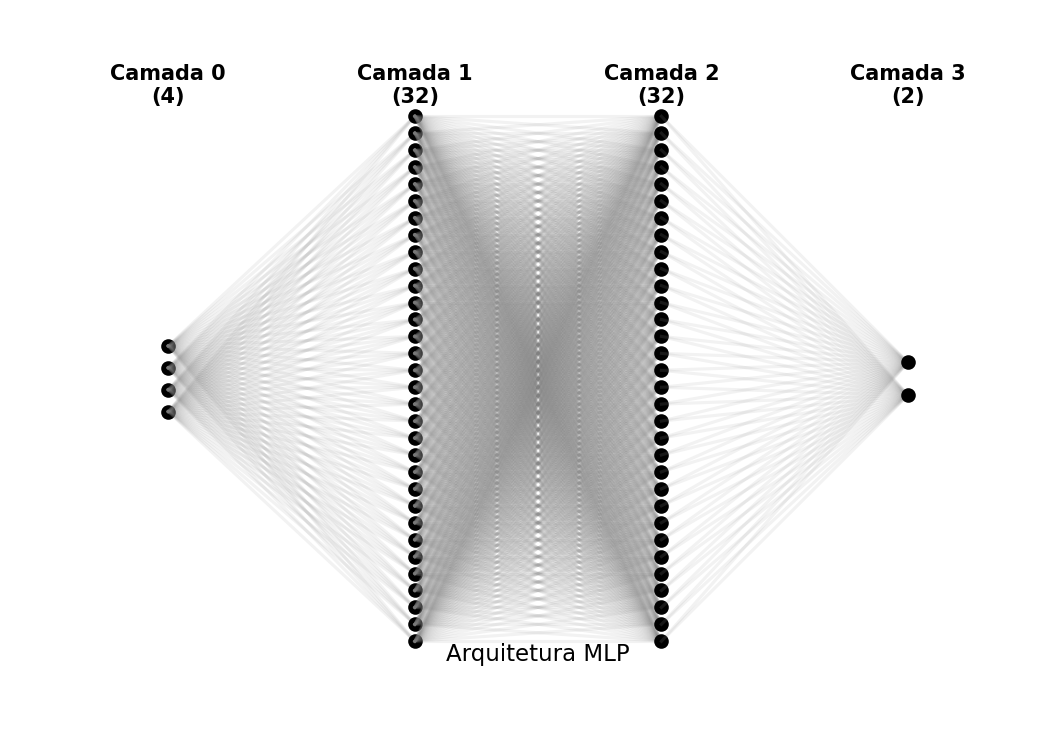

In [ ]:
plot_mlp_arquitetura(layers, grid, save_img)

##Gráficos

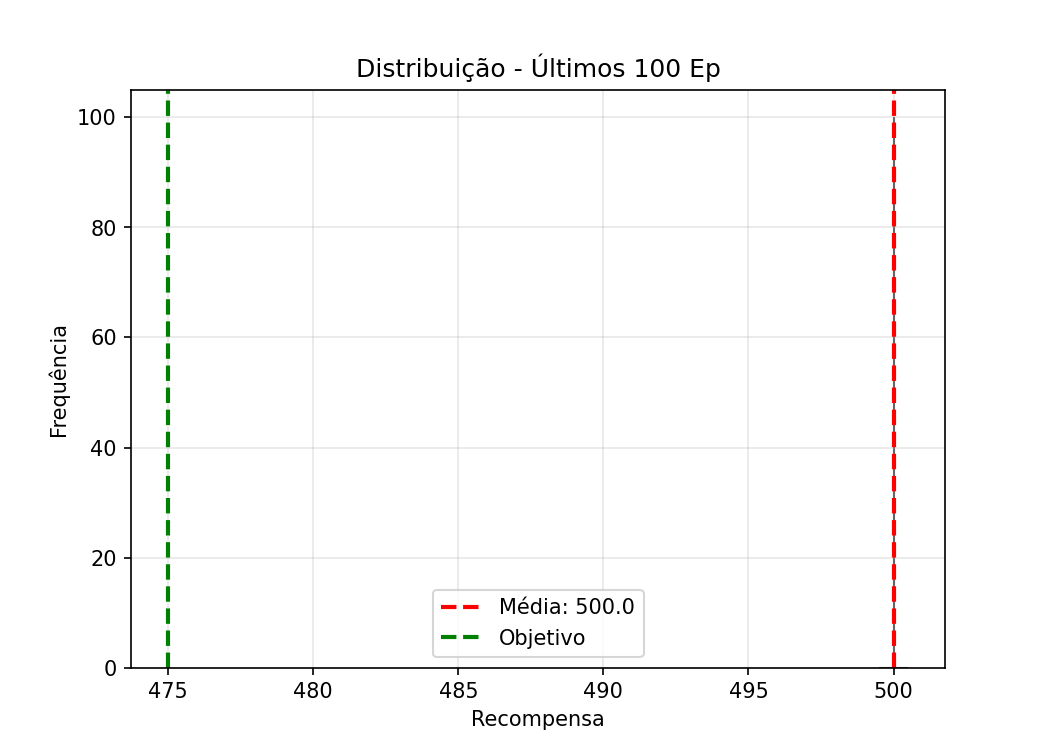

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

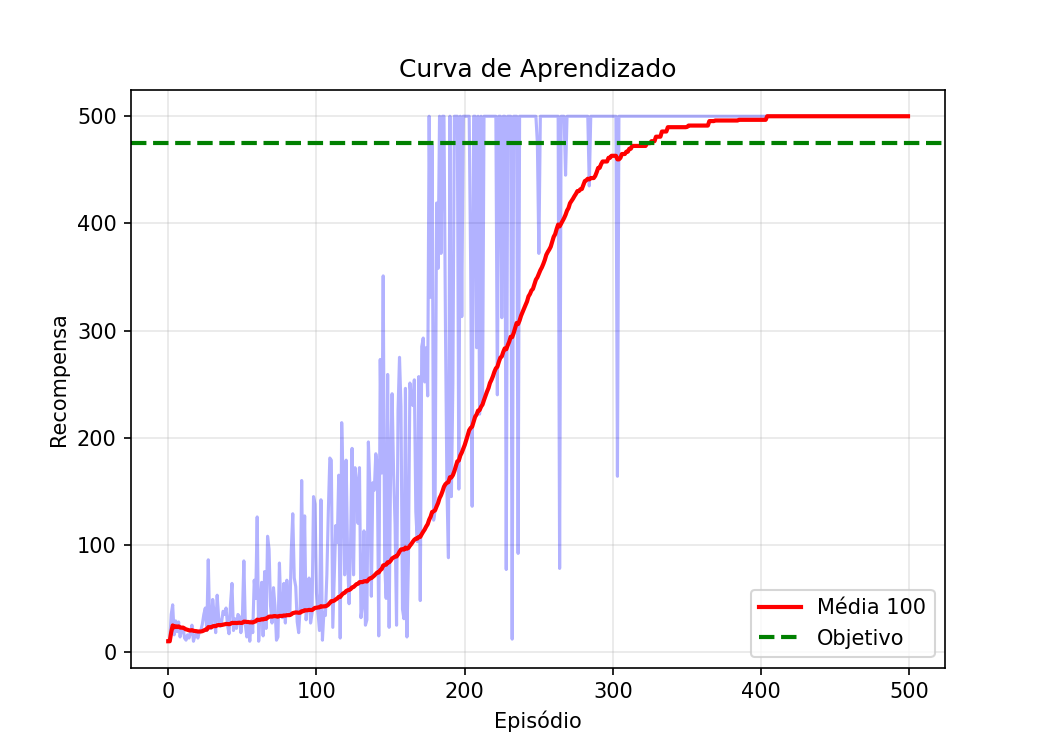

In [ ]:
plot_curva_aprendizado(rewards, save_img)

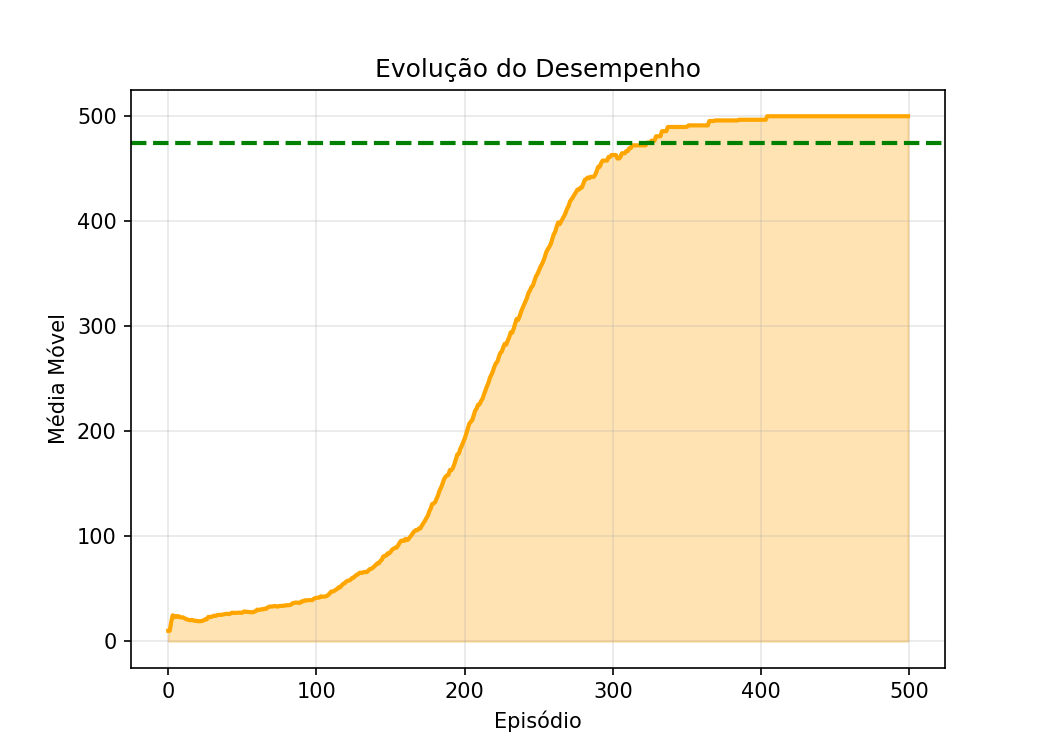

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

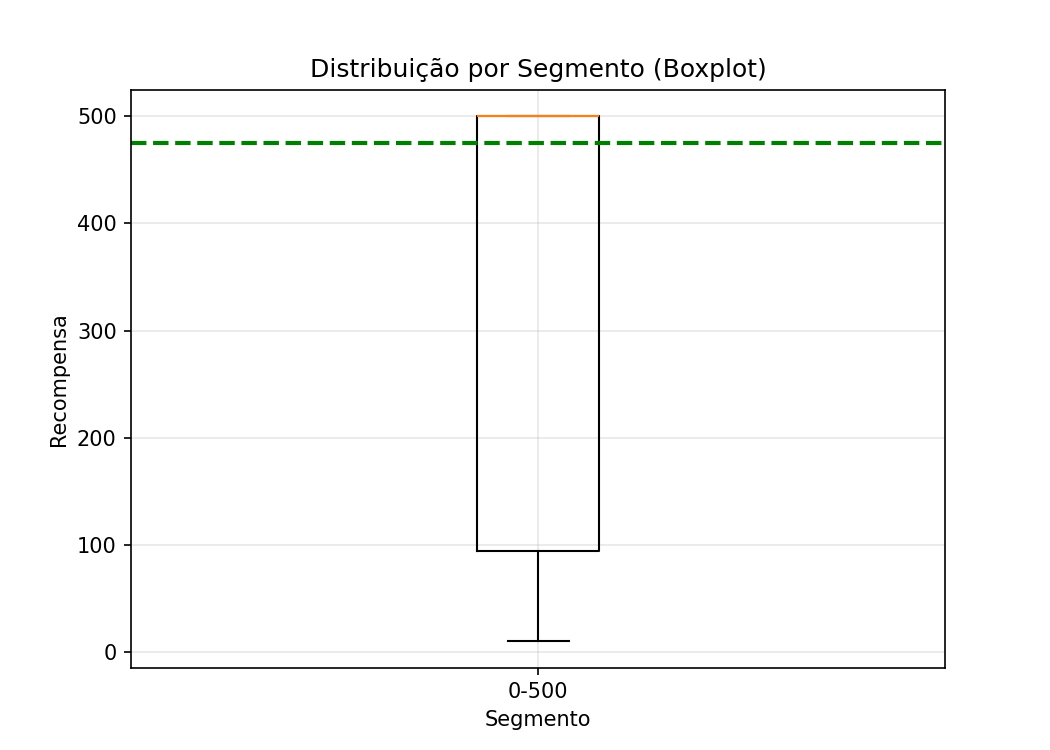

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

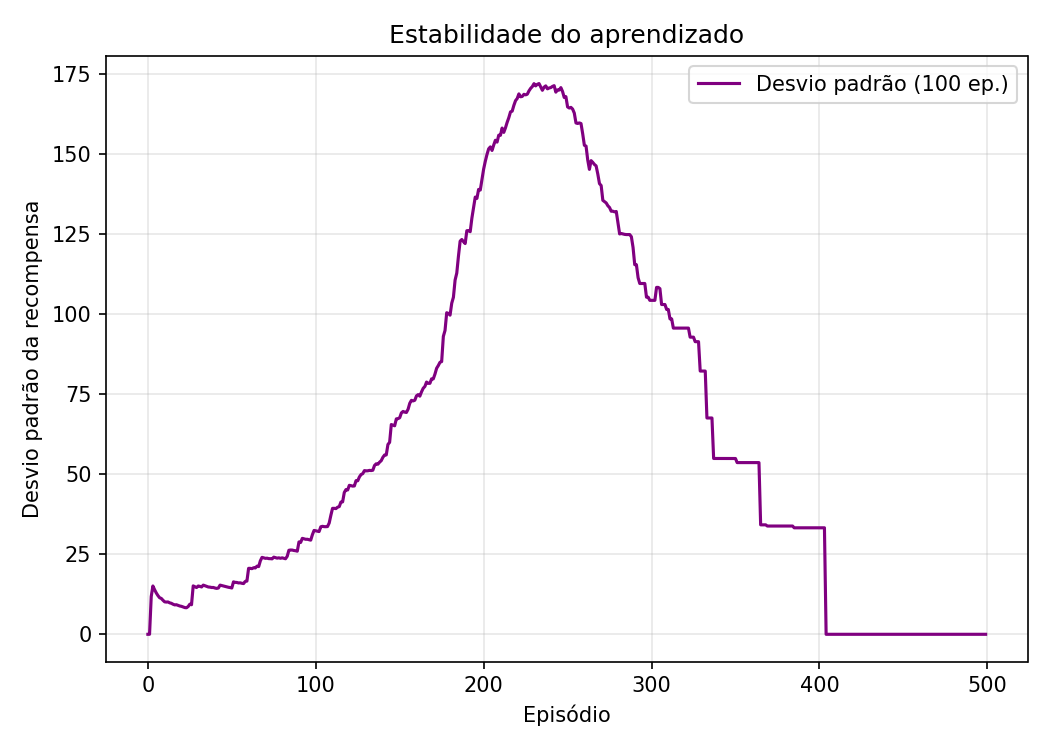

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

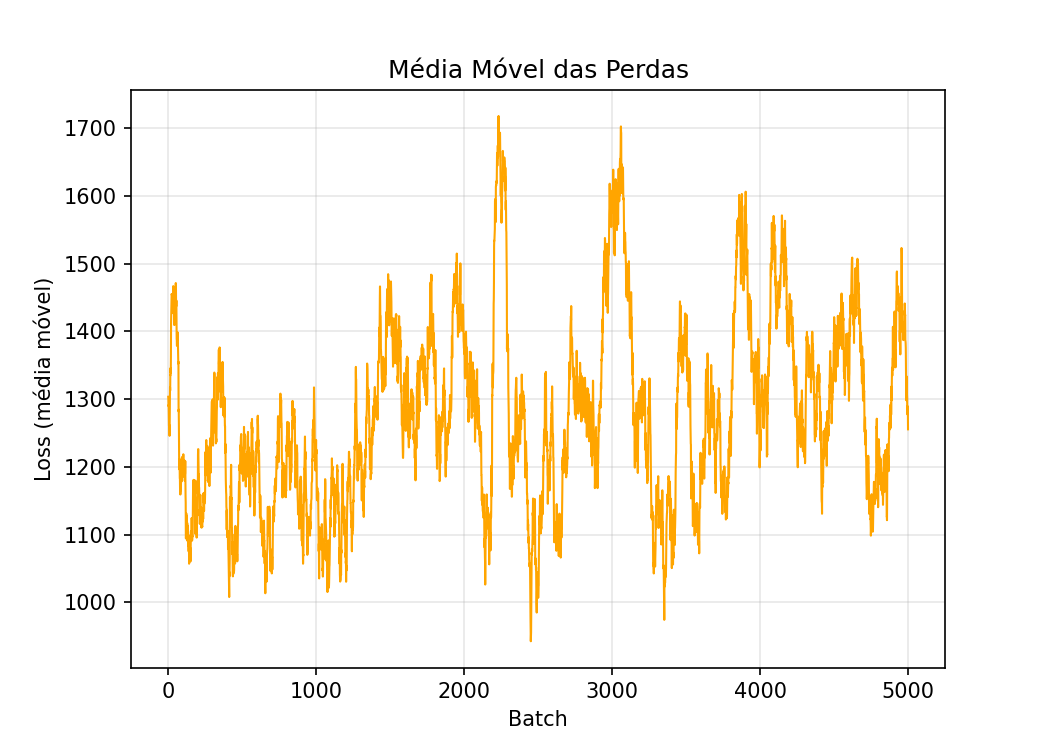

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_772fb99fa7.pt
Vídeo gerado: videos/video-0b8ae1b92f-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_772fb99fa7.pt
Vídeo gerado: videos/video-fb71a699f5-episode-0.mp4
Recompensa total: 483.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_772fb99fa7.pt
Vídeo gerado: videos/video-761f4b5bb2-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_772fb99fa7.pt
Vídeo gerado: videos/video-0c580606f2-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_772fb99fa7.pt
Vídeo gerado: videos/video-cade319f90-episode-0.mp4
Recompensa total: 500.00


#5. Executar (160)

In [ ]:
# parâmetros de execução otimizados
seed = 160
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "CartPole-v1"
num_episodes = 500
capacity = 200000
batch_size = 64
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
grid = 5
hidden_layers = [32, 32] # [32, 32]
warmup_episodes = 30

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede MLP
modelo = RLModelMLP(
    input_dim,
    hidden_layers,
    output_dim
).to(device)

# Inicializa modelo otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr=lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()
nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)

timer.stop()

(16:36:15) Iniciou execução...
Rodando na cuda:0
Ep    1/500 [WARMUP] | R:   19.00 | Media10:   19.00 | Media100:   19.00 | eps: 0.995 | Buf:     15
Ep    2/500 [WARMUP] | R:   16.00 | Media10:   17.50 | Media100:   17.50 | eps: 0.990 | Buf:     31
Ep    3/500 [WARMUP] | R:   36.00 | Media10:   23.67 | Media100:   23.67 | eps: 0.985 | Buf:     67
Ep    4/500 [WARMUP] | R:   15.00 | Media10:   21.50 | Media100:   21.50 | eps: 0.980 | Buf:     82
Ep    5/500 [WARMUP] | R:   15.00 | Media10:   20.20 | Media100:   20.20 | eps: 0.975 | Buf:     97
Ep    6/500 [WARMUP] | R:   82.00 | Media10:   30.50 | Media100:   30.50 | eps: 0.970 | Buf:    179
Ep    7/500 [WARMUP] | R:   13.00 | Media10:   28.00 | Media100:   28.00 | eps: 0.966 | Buf:    192
Ep    8/500 [WARMUP] | R:   42.00 | Media10:   29.75 | Media100:   29.75 | eps: 0.961 | Buf:    234
Ep    9/500 [WARMUP] | R:   17.00 | Media10:   28.33 | Media100:   28.33 | eps: 0.956 | Buf:    251
Ep   10/500 [WARMUP] | R:   22.00 | Media10:   27.7

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

resultados/mlp_agente_ecb98592ab.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (160)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

seed 160
device cuda
env_name CartPole-v1
num_episodes 500
capacity 200000
batch_size 64
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [32, 32]
warmup_episodes 30


##Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 171)
 Melhor média (100 ep): 500.00 (episódio 388)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelMLP(
  1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
  (model): Sequential(
    1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
    (0): Linear(160, 12.480% Params, 160.0 Mac, 11.348% MACs, in_features=4, out_features=32, bias=True)
    (1): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (2): Linear(1.06 k, 82.371% Params, 1.06 KMac, 74.894% MACs, in_features=32, out_features=32, bias=True)
    (3): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (4): Linear(66, 5.148% Params, 66.0 Mac, 4.681% MACs, in_features=32, out_features=2, bias=True)
  )
)
FLOPs (MACs): 1.41 KMac
Parâmetros: 1.28 k


##Arquitetura da Rede

In [ ]:
print(modelo)

RLModelMLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelMLP                               [1, 2]                    --
├─Sequential: 1-1                        [1, 2]                    --
│    └─Linear: 2-1                       [1, 32]                   160
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Linear: 2-3                       [1, 32]                   1,056
│    └─ReLU: 2-4                         [1, 32]                   --
│    └─Linear: 2-5                       [1, 2]                    66
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

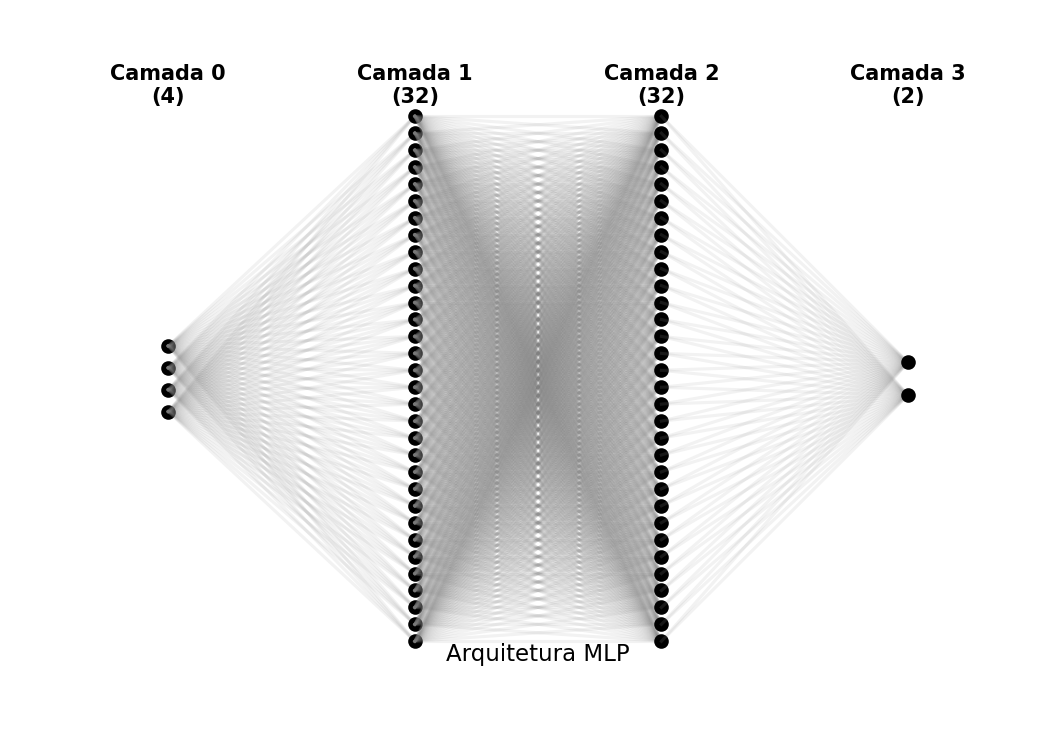

In [ ]:
plot_mlp_arquitetura(layers, grid, save_img)

##Gráficos

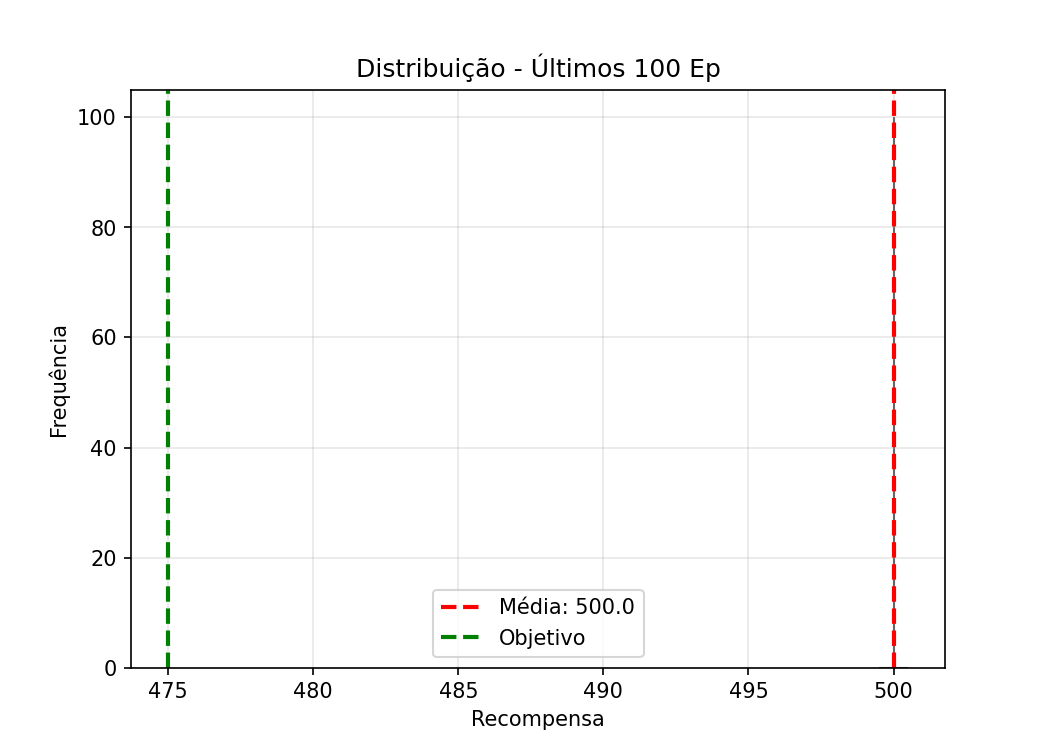

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

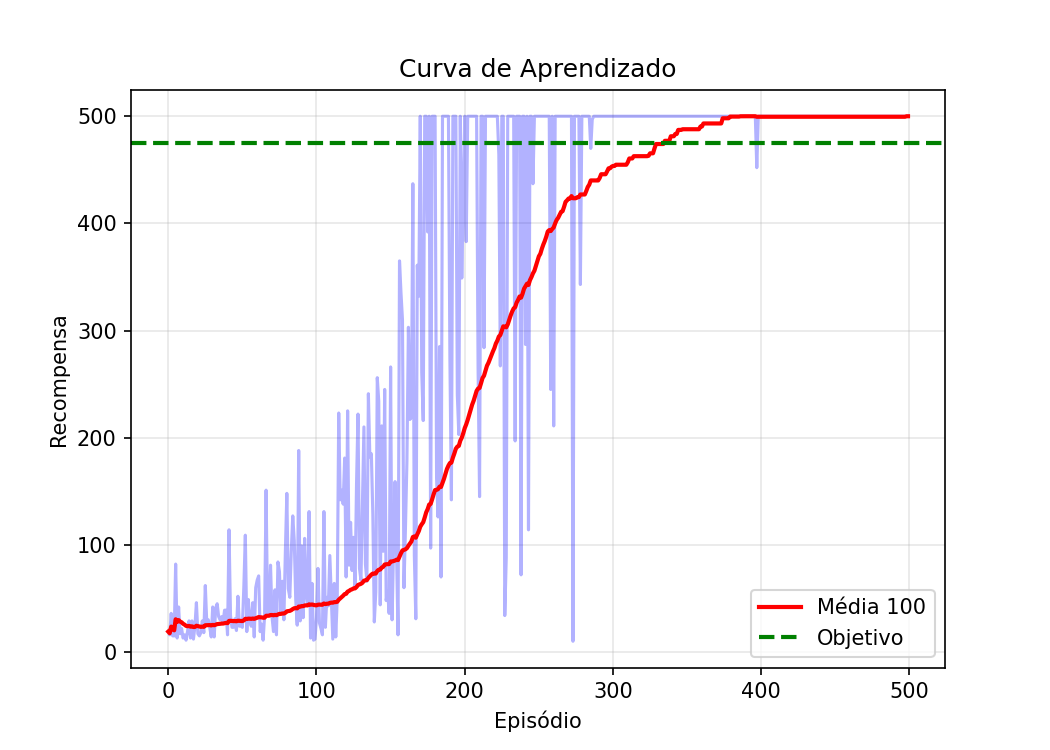

In [ ]:
plot_curva_aprendizado(rewards, save_img)

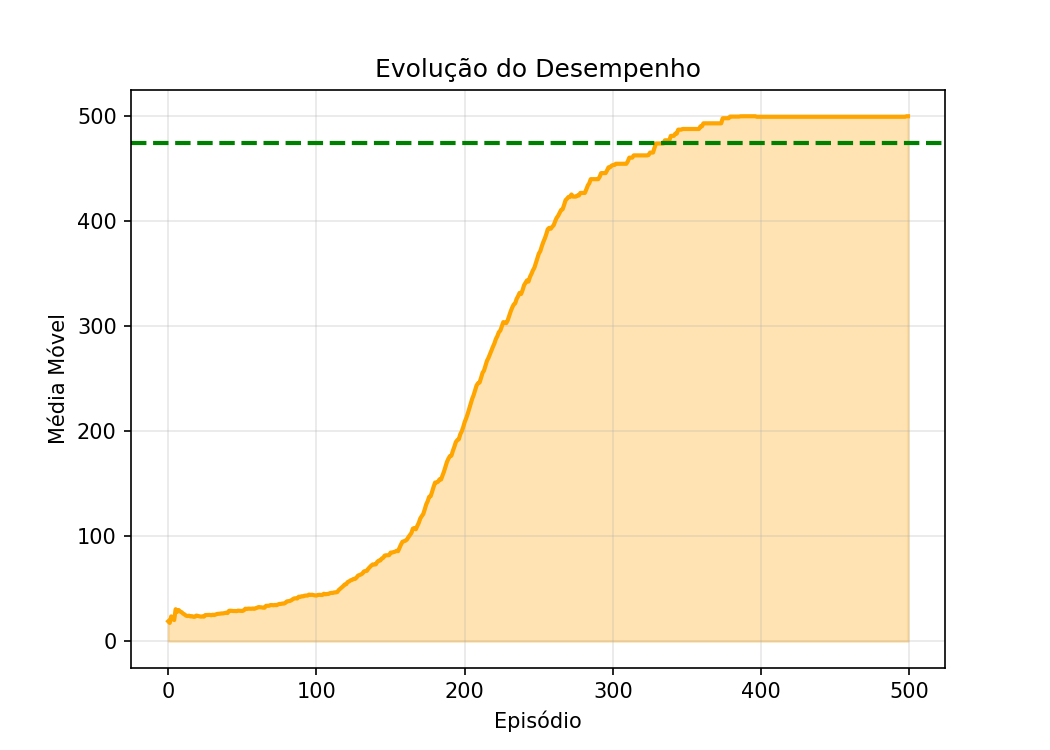

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

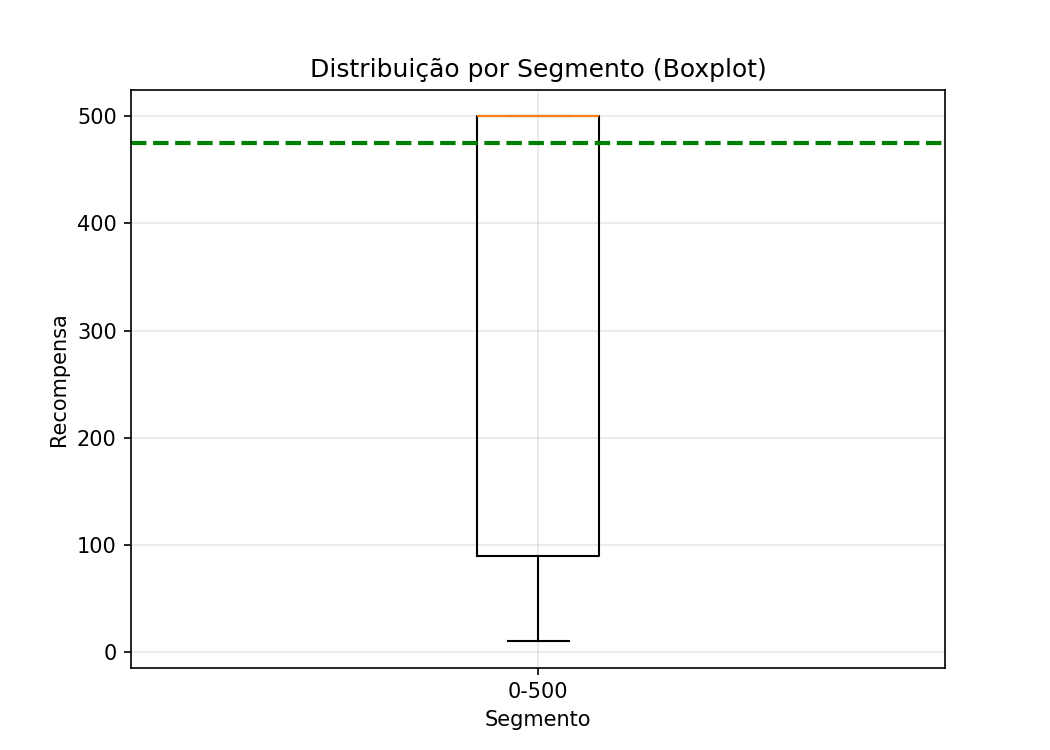

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

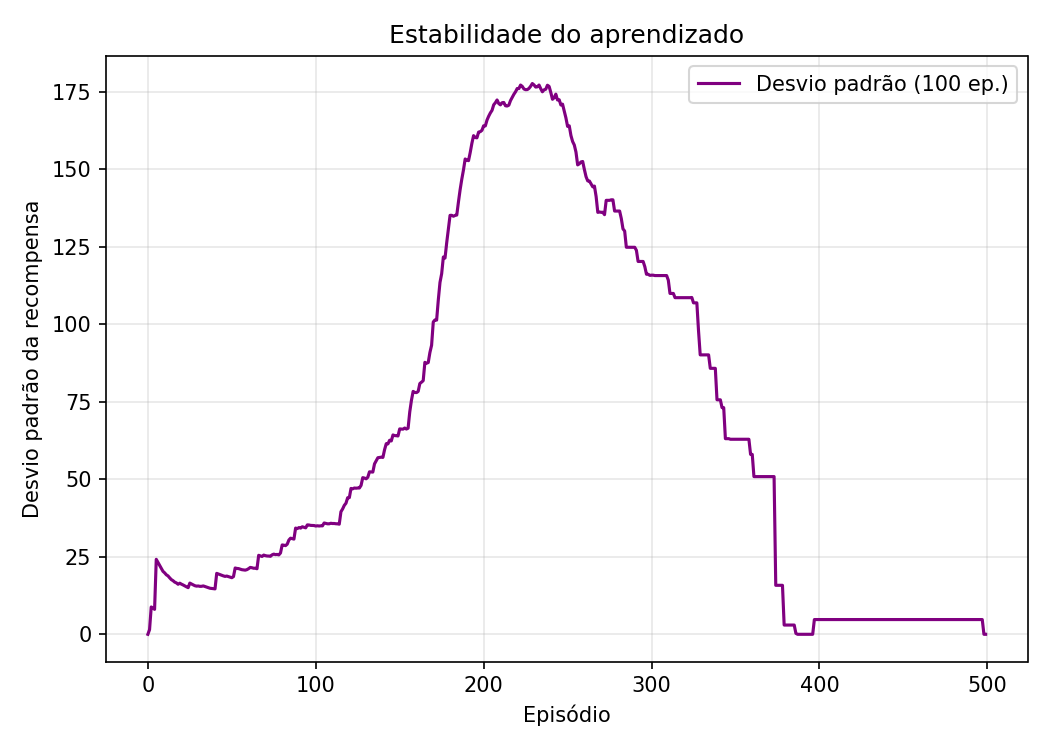

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

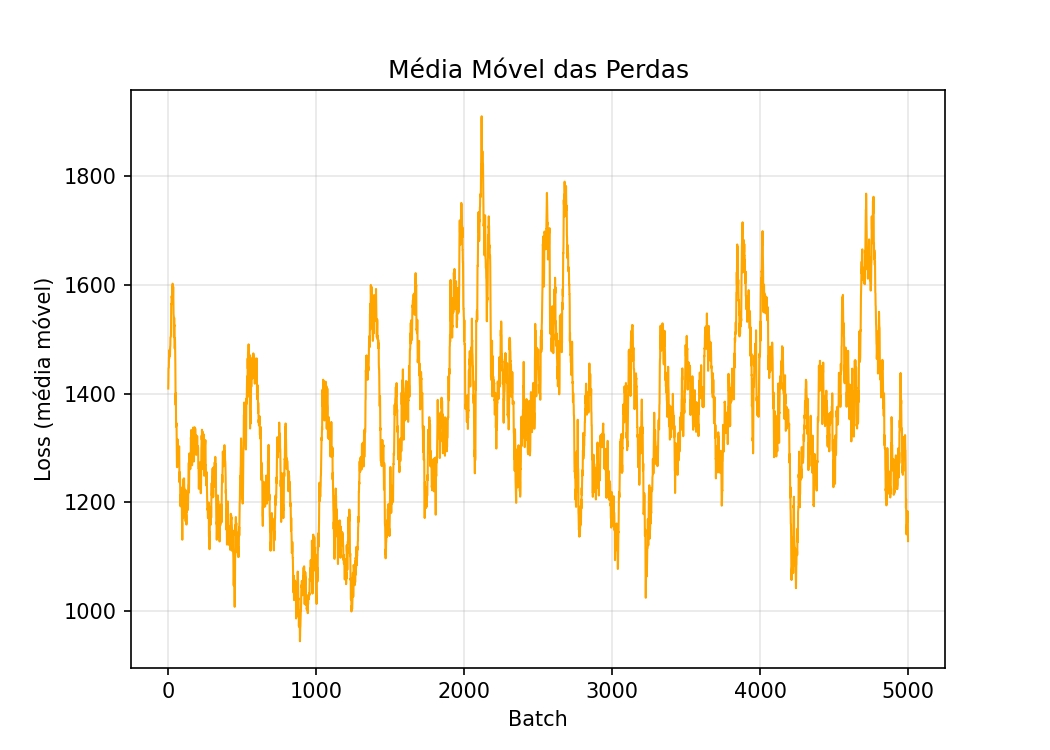

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_ecb98592ab.pt
Vídeo gerado: videos/video-8e81994c99-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_ecb98592ab.pt
Vídeo gerado: videos/video-5ae2e8f085-episode-0.mp4
Recompensa total: 464.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_ecb98592ab.pt
Vídeo gerado: videos/video-14267924c2-episode-0.mp4
Recompensa total: 470.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_ecb98592ab.pt
Vídeo gerado: videos/video-d14bf881e6-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_ecb98592ab.pt
Vídeo gerado: videos/video-712a88e481-episode-0.mp4
Recompensa total: 500.00


#5. Executar (198)

In [ ]:
# parâmetros de execução otimizados
seed = 198
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "CartPole-v1"
num_episodes = 500
capacity = 200000
batch_size = 64
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
grid = 5
hidden_layers = [32, 32]
warmup_episodes = 30

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede MLP
modelo = RLModelMLP(
    input_dim,
    hidden_layers,
    output_dim
).to(device)

# Inicializa modelo otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr=lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()
nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)

timer.stop()

(18:35:52) Iniciou execução...
Rodando na cuda:0
Ep    1/500 [WARMUP] | R:   27.00 | Media10:   27.00 | Media100:   27.00 | eps: 0.995 | Buf:     23
Ep    2/500 [WARMUP] | R:   18.00 | Media10:   22.50 | Media100:   22.50 | eps: 0.990 | Buf:     41
Ep    3/500 [WARMUP] | R:   20.00 | Media10:   21.67 | Media100:   21.67 | eps: 0.985 | Buf:     61
Ep    4/500 [WARMUP] | R:   11.00 | Media10:   19.00 | Media100:   19.00 | eps: 0.980 | Buf:     72
Ep    5/500 [WARMUP] | R:   48.00 | Media10:   24.80 | Media100:   24.80 | eps: 0.975 | Buf:    120
Ep    6/500 [WARMUP] | R:   12.00 | Media10:   22.67 | Media100:   22.67 | eps: 0.970 | Buf:    132
Ep    7/500 [WARMUP] | R:   18.00 | Media10:   22.00 | Media100:   22.00 | eps: 0.966 | Buf:    150
Ep    8/500 [WARMUP] | R:   28.00 | Media10:   22.75 | Media100:   22.75 | eps: 0.961 | Buf:    178
Ep    9/500 [WARMUP] | R:   22.00 | Media10:   22.67 | Media100:   22.67 | eps: 0.956 | Buf:    200
Ep   10/500 [WARMUP] | R:   21.00 | Media10:   22.5

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

resultados/mlp_agente_057eb7441b.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (198)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

seed 198
device cuda
env_name CartPole-v1
num_episodes 500
capacity 200000
batch_size 64
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [32, 32]
warmup_episodes 30


##Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 170)
 Melhor média (100 ep): 495.14 (episódio 382)
 Média últimos (100 ep): 452.79 ± 106.76
 Taxa de sucesso (>475): 81.0% (81/100)
Conclusão:
 BOM! Agente próximo de resolver.


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelMLP(
  1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
  (model): Sequential(
    1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
    (0): Linear(160, 12.480% Params, 160.0 Mac, 11.348% MACs, in_features=4, out_features=32, bias=True)
    (1): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (2): Linear(1.06 k, 82.371% Params, 1.06 KMac, 74.894% MACs, in_features=32, out_features=32, bias=True)
    (3): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (4): Linear(66, 5.148% Params, 66.0 Mac, 4.681% MACs, in_features=32, out_features=2, bias=True)
  )
)
FLOPs (MACs): 1.41 KMac
Parâmetros: 1.28 k


##Arquitetura da Rede

In [ ]:
print(modelo)

RLModelMLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelMLP                               [1, 2]                    --
├─Sequential: 1-1                        [1, 2]                    --
│    └─Linear: 2-1                       [1, 32]                   160
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Linear: 2-3                       [1, 32]                   1,056
│    └─ReLU: 2-4                         [1, 32]                   --
│    └─Linear: 2-5                       [1, 2]                    66
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

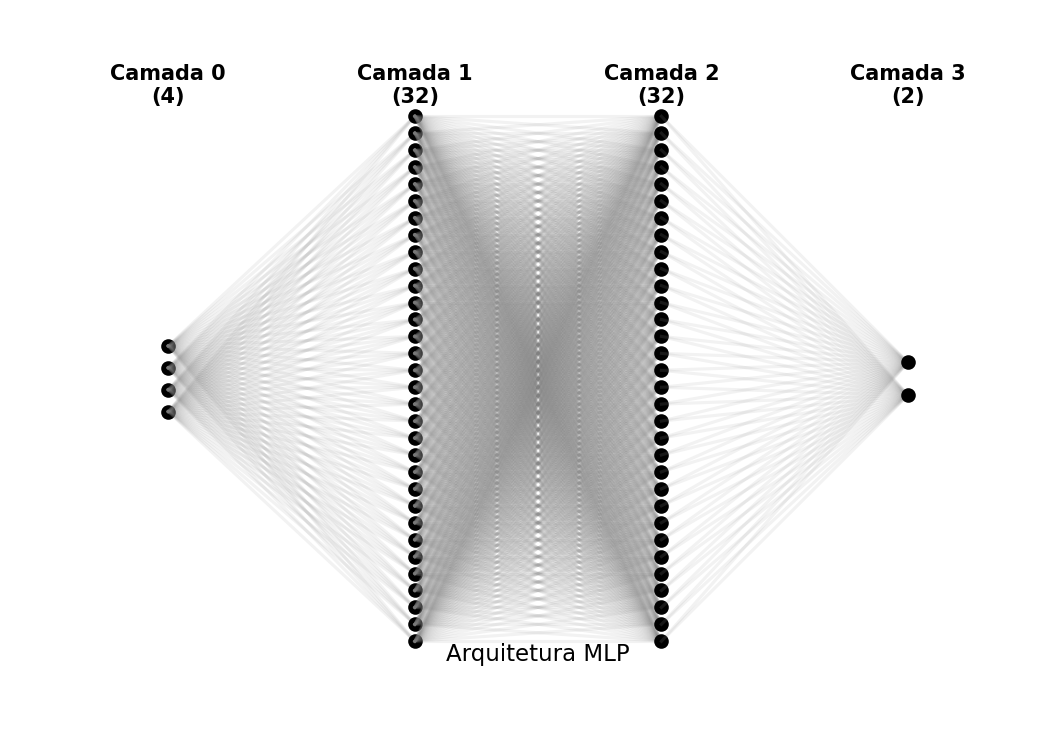

In [ ]:
plot_mlp_arquitetura(layers, grid, save_img)

##Gráficos

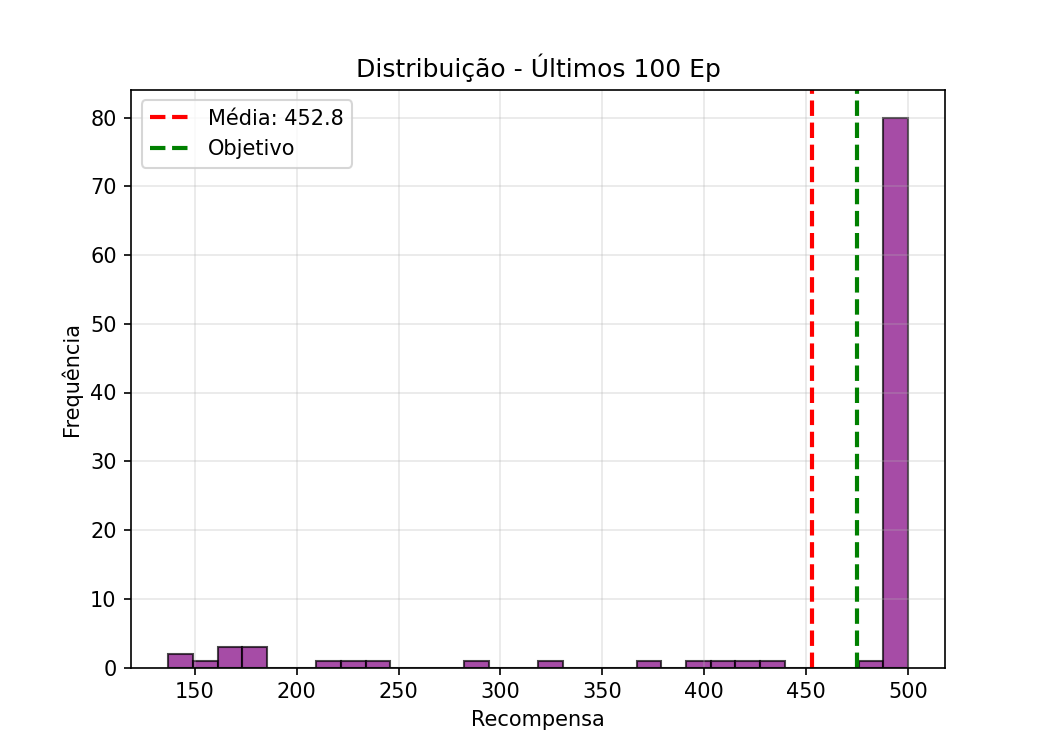

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

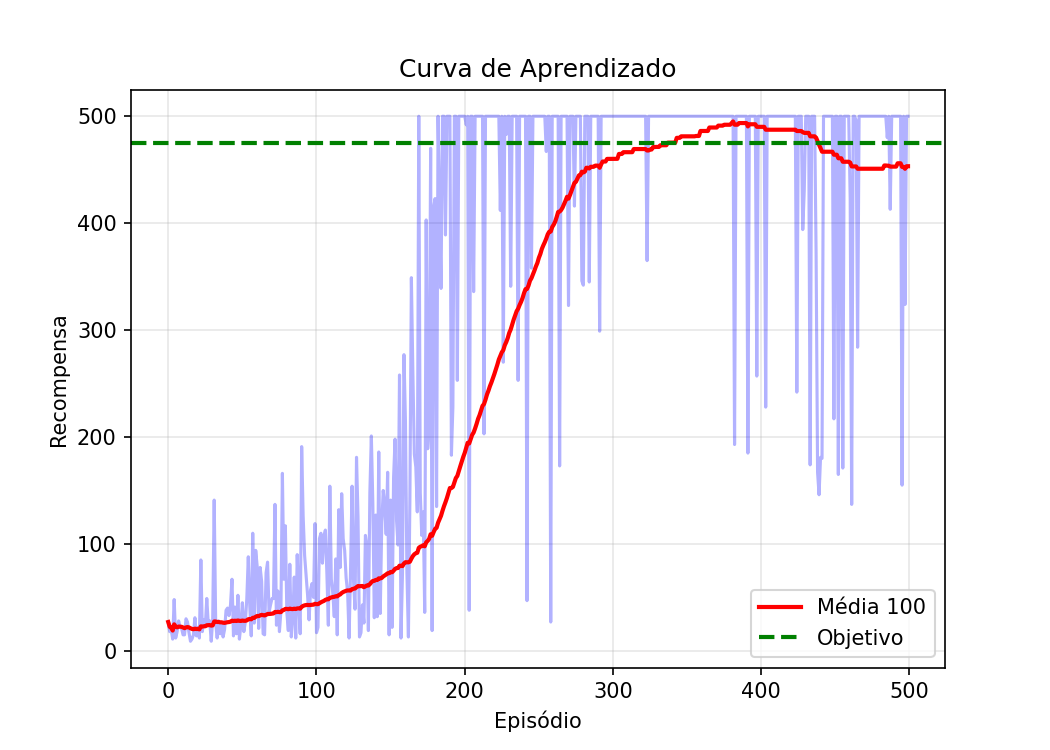

In [ ]:
plot_curva_aprendizado(rewards, save_img)

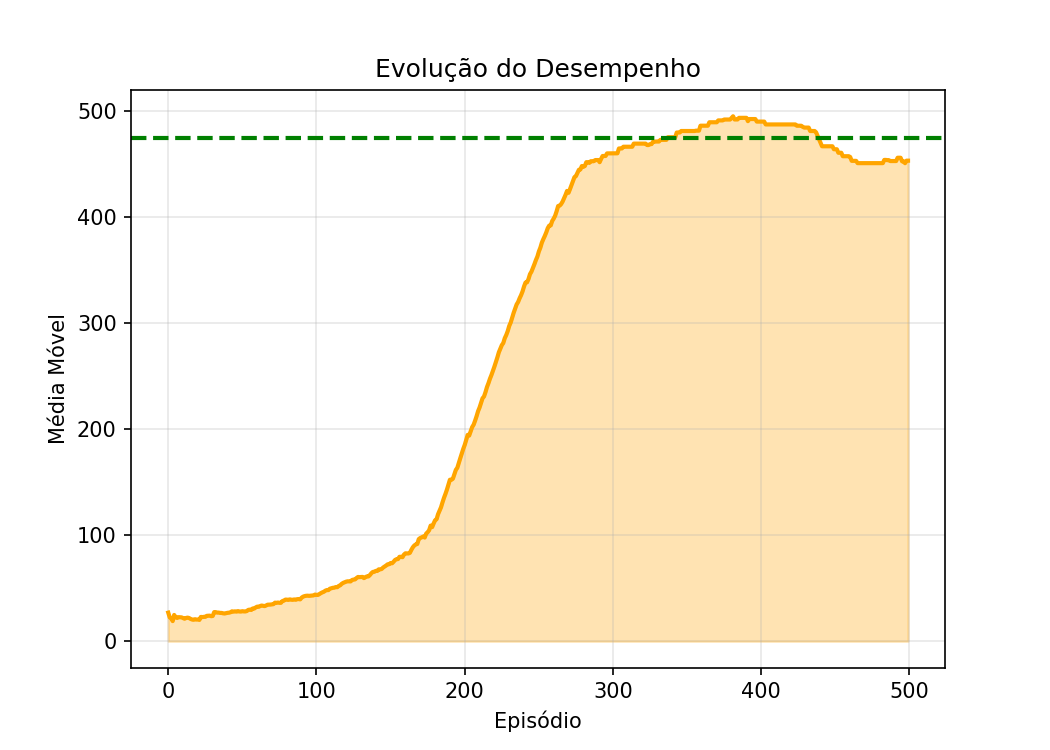

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

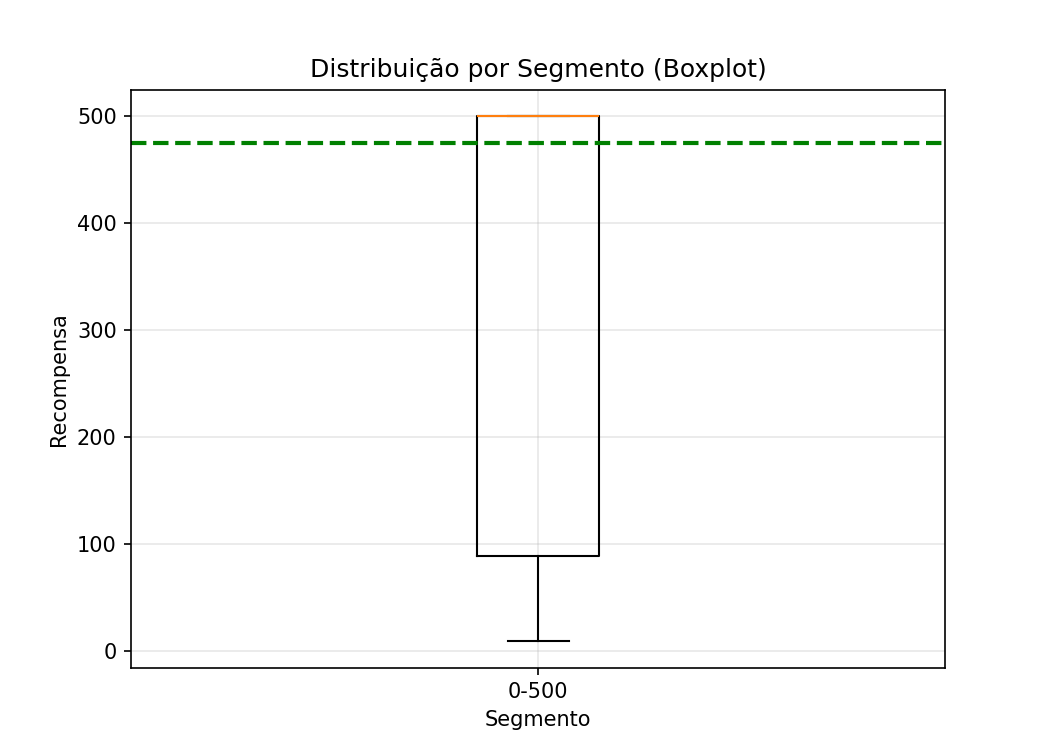

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

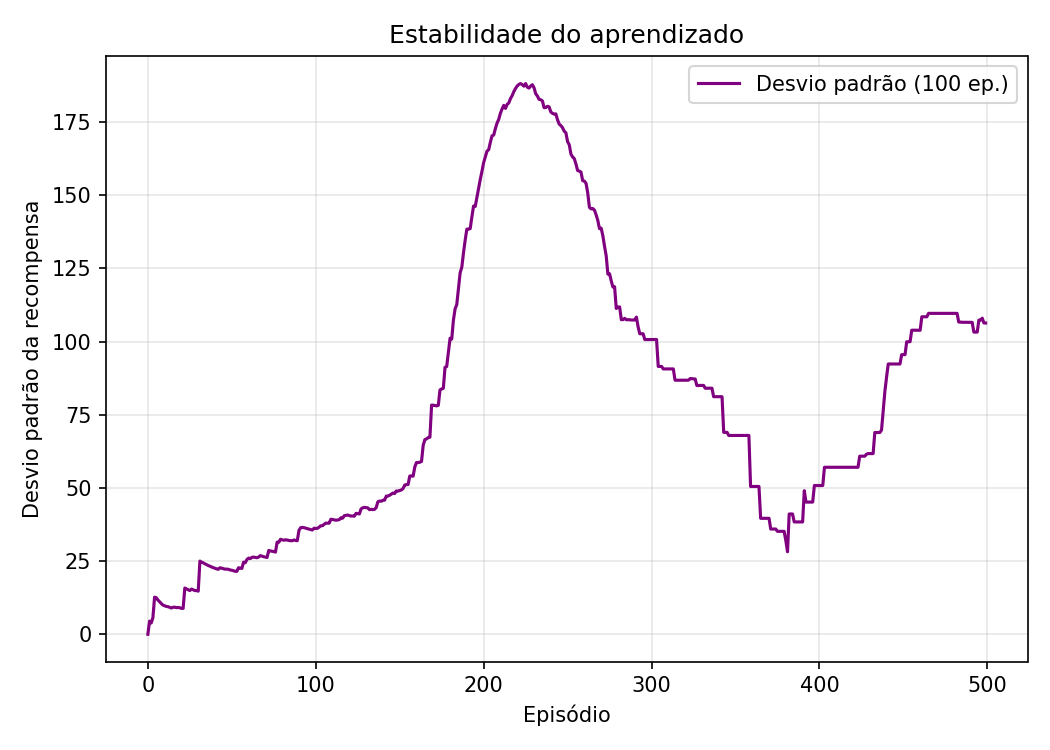

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

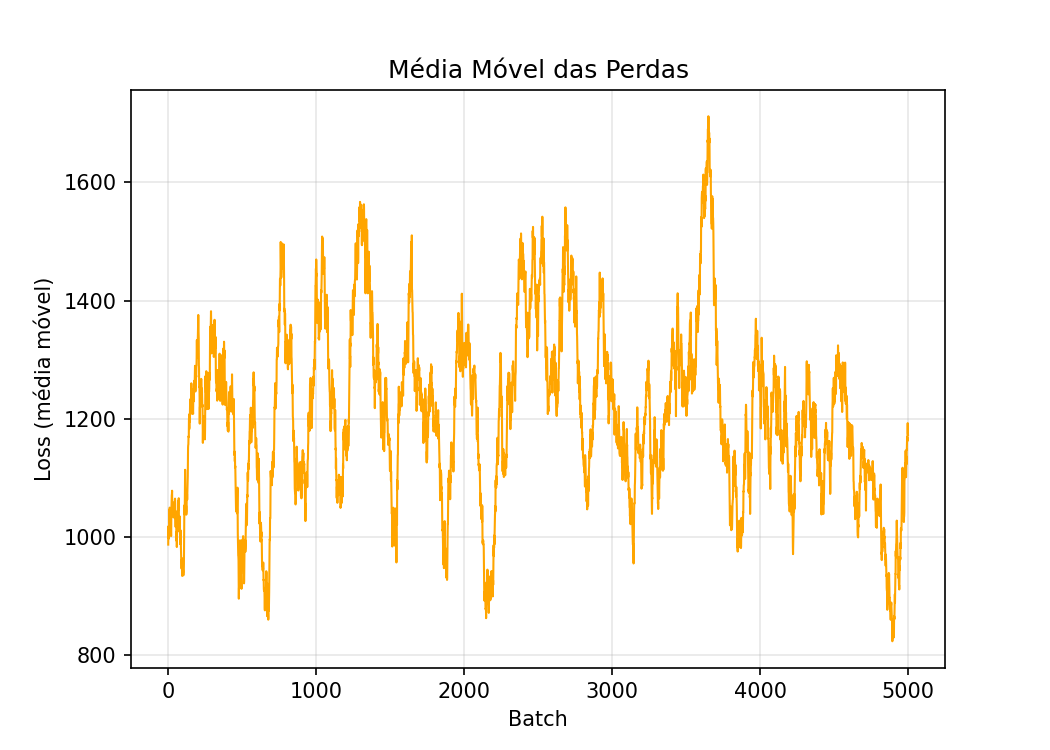

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_057eb7441b.pt
Vídeo gerado: videos/video-068bf61bcc-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_057eb7441b.pt
Vídeo gerado: videos/video-c2f63cc30d-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_057eb7441b.pt
Vídeo gerado: videos/video-07900eb3de-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_057eb7441b.pt
Vídeo gerado: videos/video-5b7bced31e-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_057eb7441b.pt
Vídeo gerado: videos/video-c38dd035a7-episode-0.mp4
Recompensa total: 500.00


#5. Executar (254)

In [ ]:
# parâmetros de execução otimizados
seed = 254
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "CartPole-v1"
num_episodes = 500
capacity = 200000
batch_size = 64
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
grid = 5
hidden_layers = [32, 32] # [32, 32]
warmup_episodes = 30

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede MLP
modelo = RLModelMLP(
    input_dim,
    hidden_layers,
    output_dim
).to(device)

# Inicializa modelo otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr=lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()
nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)

timer.stop()

(17:16:45) Iniciou execução...
Rodando na cuda:0
Ep    1/500 [WARMUP] | R:   21.00 | Media10:   21.00 | Media100:   21.00 | eps: 0.995 | Buf:     17
Ep    2/500 [WARMUP] | R:   14.00 | Media10:   17.50 | Media100:   17.50 | eps: 0.990 | Buf:     31
Ep    3/500 [WARMUP] | R:   22.00 | Media10:   19.00 | Media100:   19.00 | eps: 0.985 | Buf:     53
Ep    4/500 [WARMUP] | R:   13.00 | Media10:   17.50 | Media100:   17.50 | eps: 0.980 | Buf:     66
Ep    5/500 [WARMUP] | R:   29.00 | Media10:   19.80 | Media100:   19.80 | eps: 0.975 | Buf:     95
Ep    6/500 [WARMUP] | R:   15.00 | Media10:   19.00 | Media100:   19.00 | eps: 0.970 | Buf:    110
Ep    7/500 [WARMUP] | R:   22.00 | Media10:   19.43 | Media100:   19.43 | eps: 0.966 | Buf:    132
Ep    8/500 [WARMUP] | R:   12.00 | Media10:   18.50 | Media100:   18.50 | eps: 0.961 | Buf:    144
Ep    9/500 [WARMUP] | R:   26.00 | Media10:   19.33 | Media100:   19.33 | eps: 0.956 | Buf:    170
Ep   10/500 [WARMUP] | R:   17.00 | Media10:   19.1

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

resultados/mlp_agente_b6a5ad87cd.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (254)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

seed 254
device cuda
env_name CartPole-v1
num_episodes 500
capacity 200000
batch_size 64
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [32, 32]
warmup_episodes 30


##Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 149)
 Melhor média (100 ep): 500.00 (episódio 357)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 149)
 Melhor média (100 ep): 500.00 (episódio 357)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 149)
 Melhor média (100 ep): 500.00 (episódio 357)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 149)
 Melhor média (100 ep): 500.00 (episódio 357)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelMLP(
  1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
  (model): Sequential(
    1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
    (0): Linear(160, 12.480% Params, 160.0 Mac, 11.348% MACs, in_features=4, out_features=32, bias=True)
    (1): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (2): Linear(1.06 k, 82.371% Params, 1.06 KMac, 74.894% MACs, in_features=32, out_features=32, bias=True)
    (3): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (4): Linear(66, 5.148% Params, 66.0 Mac, 4.681% MACs, in_features=32, out_features=2, bias=True)
  )
)
FLOPs (MACs): 1.41 KMac
Parâmetros: 1.28 k


##Arquitetura da Rede

In [ ]:
print(modelo)

RLModelMLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelMLP                               [1, 2]                    --
├─Sequential: 1-1                        [1, 2]                    --
│    └─Linear: 2-1                       [1, 32]                   160
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Linear: 2-3                       [1, 32]                   1,056
│    └─ReLU: 2-4                         [1, 32]                   --
│    └─Linear: 2-5                       [1, 2]                    66
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

/tmp/ipykernel_6365/3599288320.py:282: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


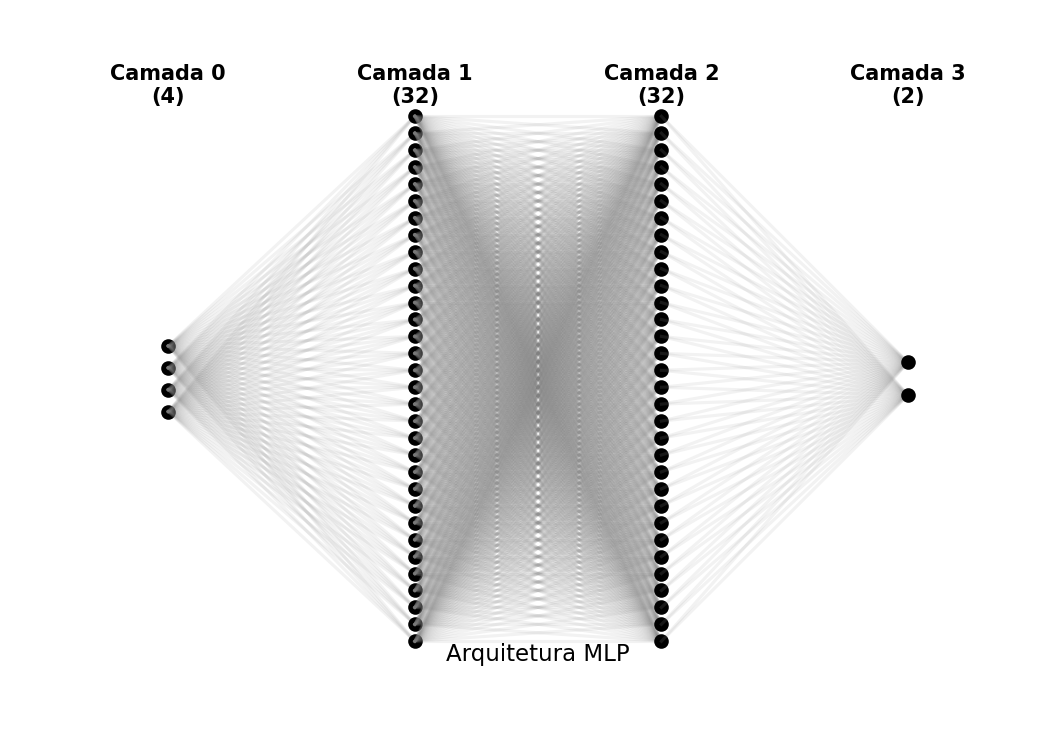

In [ ]:
plot_mlp_arquitetura(layers, grid, save_img)

##Gráficos

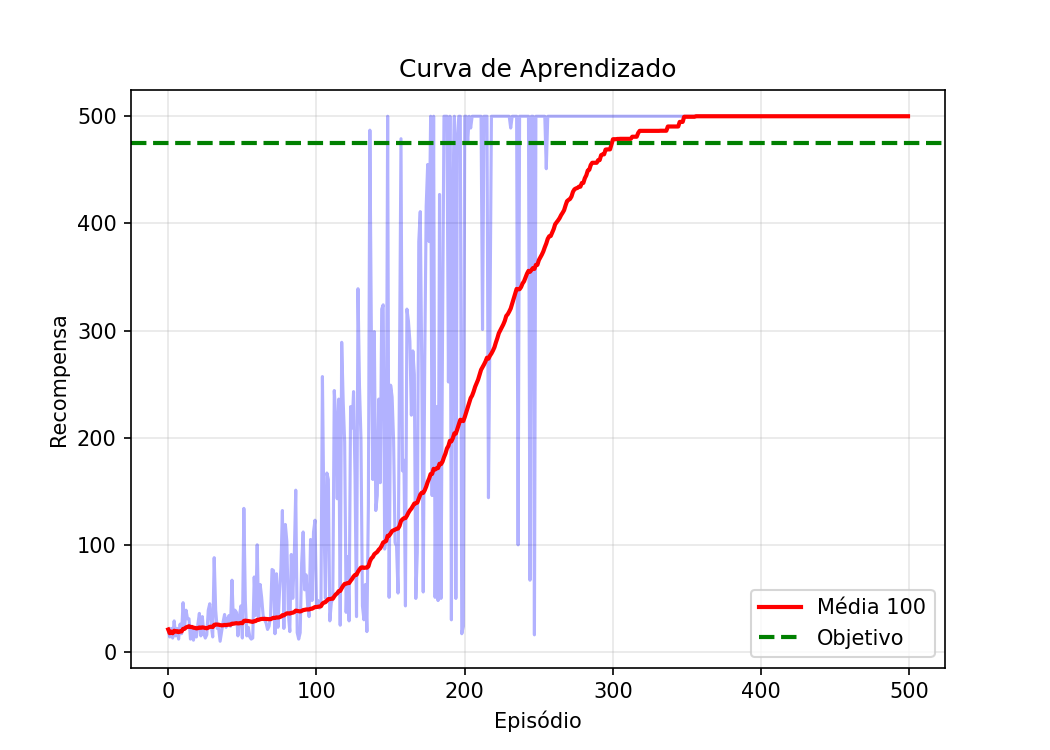

In [ ]:
plot_curva_aprendizado(rewards, save_img)

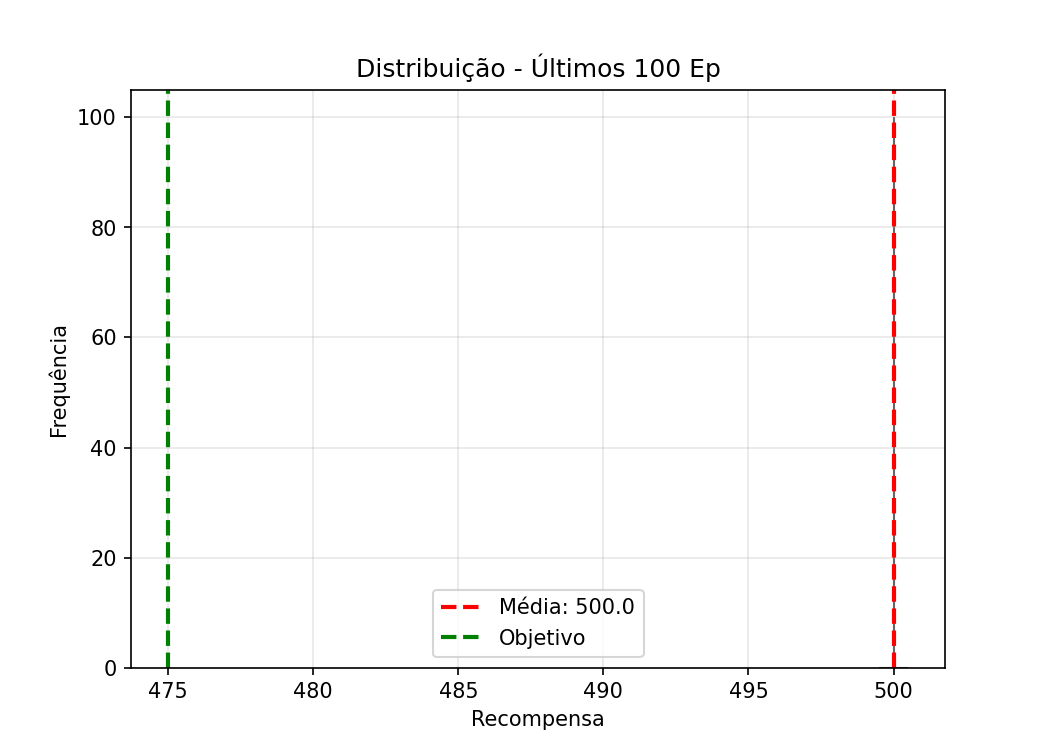

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

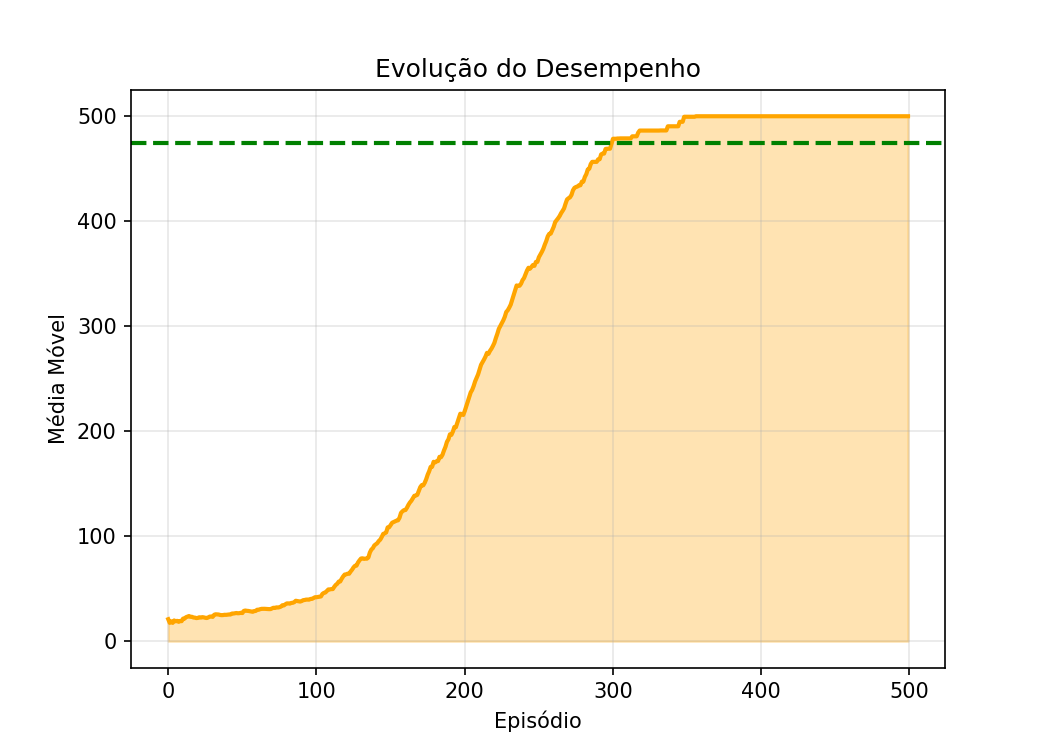

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

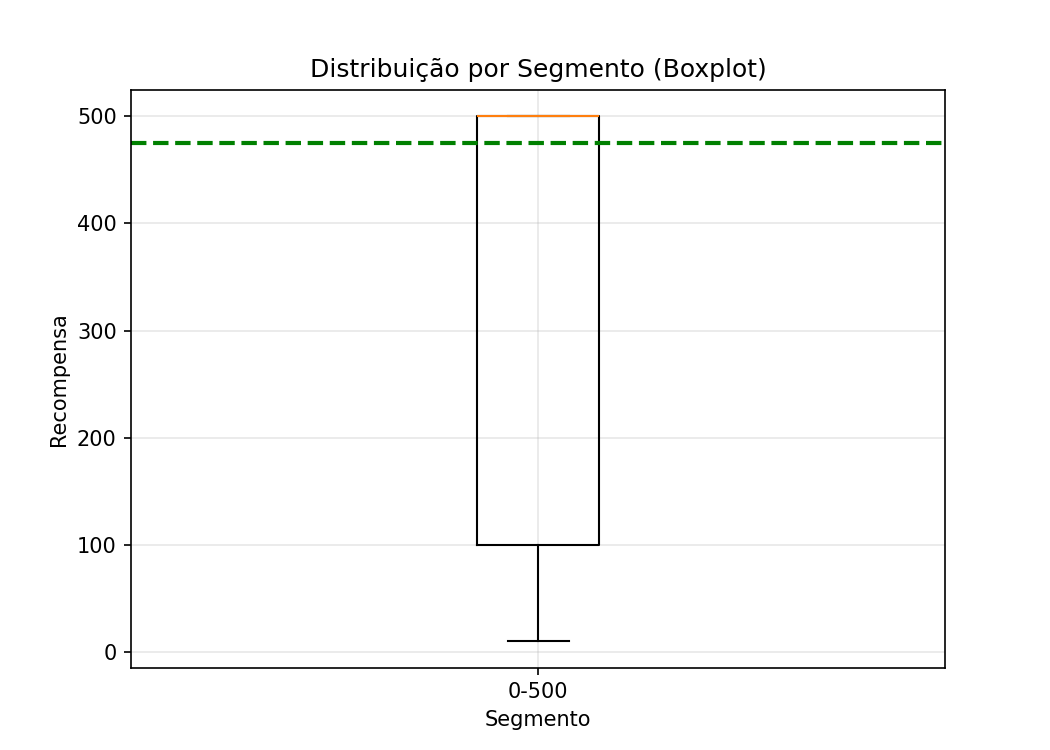

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

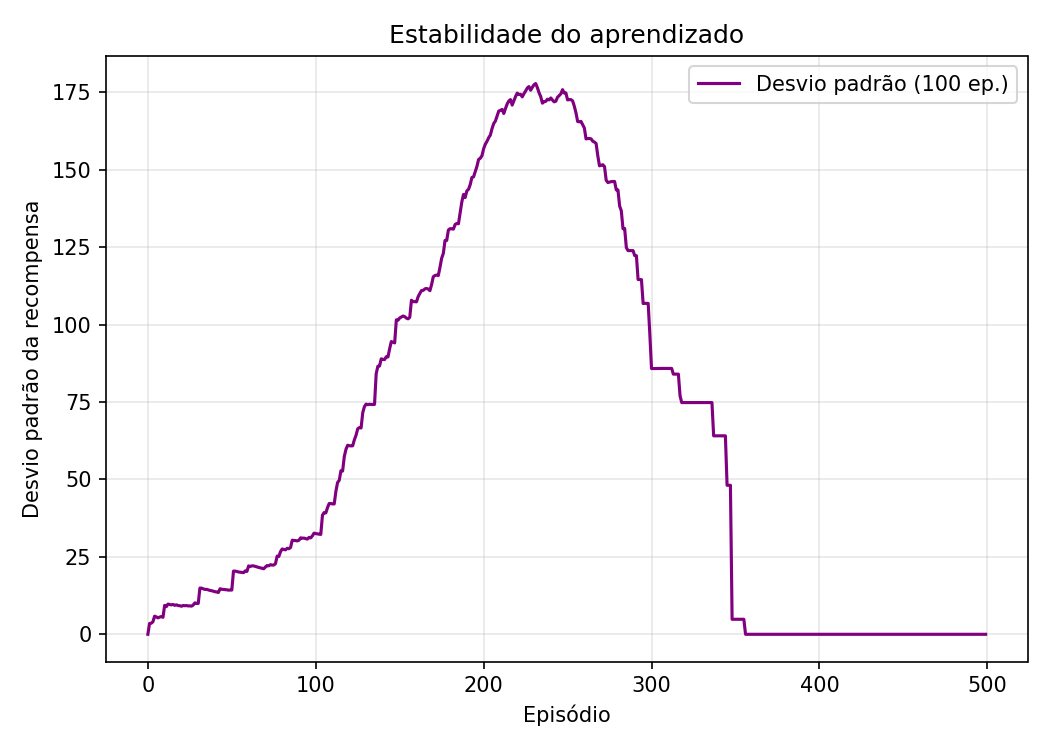

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

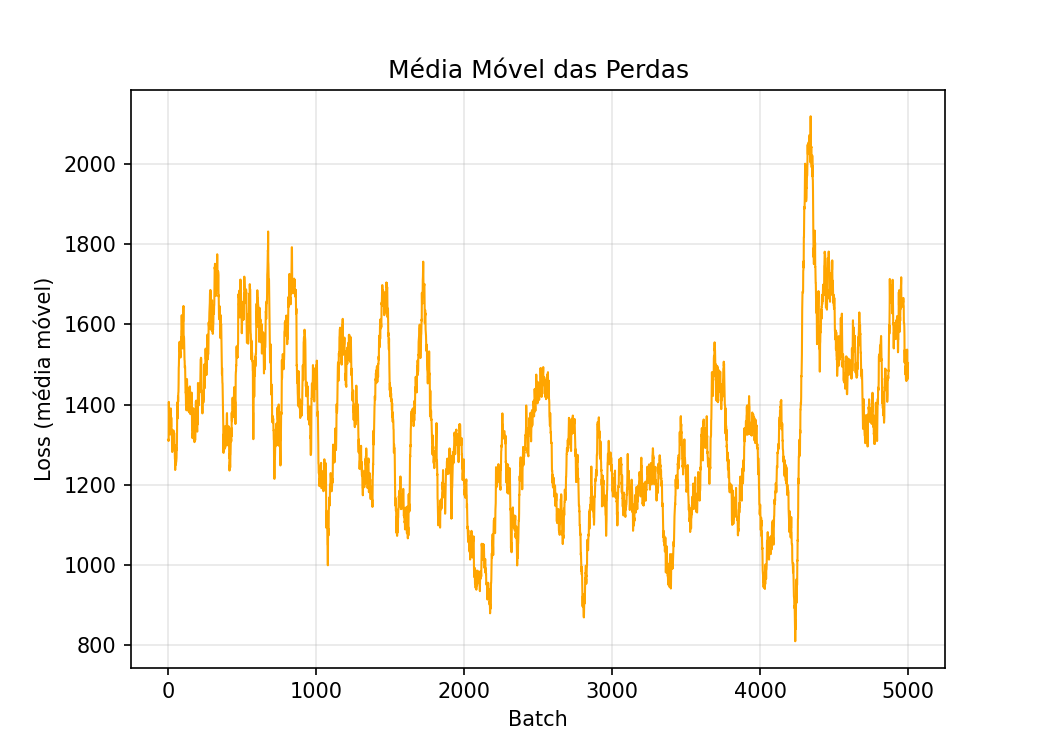

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_b6a5ad87cd.pt
Vídeo gerado: videos/video-94204a835e-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_b6a5ad87cd.pt
Vídeo gerado: videos/video-06e4b5b74e-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_b6a5ad87cd.pt
Vídeo gerado: videos/video-b0cb75cf76-episode-0.mp4
Recompensa total: 413.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_b6a5ad87cd.pt
Vídeo gerado: videos/video-03c217c59c-episode-0.mp4
Recompensa total: 387.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_b6a5ad87cd.pt
Vídeo gerado: videos/video-0097dc339d-episode-0.mp4
Recompensa total: 500.00


#5. Executar (2026)

In [ ]:
# parâmetros de execução otimizados
seed = 2026
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "CartPole-v1"
num_episodes = 500
capacity = 200000
batch_size = 64
n_step = 5
tau = 1.0
gamma = 0.99
lr = 1e-3
grid = 5
hidden_layers = [32, 32] # [32, 32]
warmup_episodes = 30

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
layers = [input_dim] + hidden_layers + [output_dim]

# Configuração da rede MLP
modelo = RLModelMLP(
    input_dim,
    hidden_layers,
    output_dim
).to(device)

# Inicializa modelo otimizador, agente e buffer
optimizer = optim.Adam(modelo.parameters(), lr=lr)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()
nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)

timer.stop()

(15:58:46) Iniciou execução...
Rodando na cuda:0
Ep    1/500 [WARMUP] | R:   17.00 | Media10:   17.00 | Media100:   17.00 | eps: 0.995 | Buf:     13
Ep    2/500 [WARMUP] | R:   16.00 | Media10:   16.50 | Media100:   16.50 | eps: 0.990 | Buf:     29
Ep    3/500 [WARMUP] | R:   12.00 | Media10:   15.00 | Media100:   15.00 | eps: 0.985 | Buf:     41
Ep    4/500 [WARMUP] | R:   34.00 | Media10:   19.75 | Media100:   19.75 | eps: 0.980 | Buf:     75
Ep    5/500 [WARMUP] | R:   14.00 | Media10:   18.60 | Media100:   18.60 | eps: 0.975 | Buf:     89
Ep    6/500 [WARMUP] | R:   15.00 | Media10:   18.00 | Media100:   18.00 | eps: 0.970 | Buf:    104
Ep    7/500 [WARMUP] | R:   20.00 | Media10:   18.29 | Media100:   18.29 | eps: 0.966 | Buf:    124
Ep    8/500 [WARMUP] | R:   18.00 | Media10:   18.25 | Media100:   18.25 | eps: 0.961 | Buf:    142
Ep    9/500 [WARMUP] | R:   17.00 | Media10:   18.11 | Media100:   18.11 | eps: 0.956 | Buf:    159
Ep   10/500 [WARMUP] | R:   30.00 | Media10:   19.3

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'{caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

resultados/mlp_agente_5d98dbebc0.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (2026)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

seed 2026
device cuda
env_name CartPole-v1
num_episodes 500
capacity 200000
batch_size 64
n_step 5
tau 1.0
gamma 0.99
lr 0.001
hidden_layers [32, 32]
warmup_episodes 30


##Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 156)
 Melhor média (100 ep): 500.00 (episódio 439)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 156)
 Melhor média (100 ep): 500.00 (episódio 439)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 156)
 Melhor média (100 ep): 500.00 (episódio 439)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 500.00 (episódio 156)
 Melhor média (100 ep): 500.00 (episódio 439)
 Média últimos (100 ep): 500.00 ± 0.00
 Taxa de sucesso (>475): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelMLP(
  1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
  (model): Sequential(
    1.28 k, 100.000% Params, 1.35 KMac, 95.461% MACs, 
    (0): Linear(160, 12.480% Params, 160.0 Mac, 11.348% MACs, in_features=4, out_features=32, bias=True)
    (1): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (2): Linear(1.06 k, 82.371% Params, 1.06 KMac, 74.894% MACs, in_features=32, out_features=32, bias=True)
    (3): ReLU(0, 0.000% Params, 32.0 Mac, 2.270% MACs, )
    (4): Linear(66, 5.148% Params, 66.0 Mac, 4.681% MACs, in_features=32, out_features=2, bias=True)
  )
)
FLOPs (MACs): 1.41 KMac
Parâmetros: 1.28 k


##Arquitetura da Rede

In [ ]:
print(modelo)

RLModelMLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelMLP                               [1, 2]                    --
├─Sequential: 1-1                        [1, 2]                    --
│    └─Linear: 2-1                       [1, 32]                   160
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Linear: 2-3                       [1, 32]                   1,056
│    └─ReLU: 2-4                         [1, 32]                   --
│    └─Linear: 2-5                       [1, 2]                    66
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

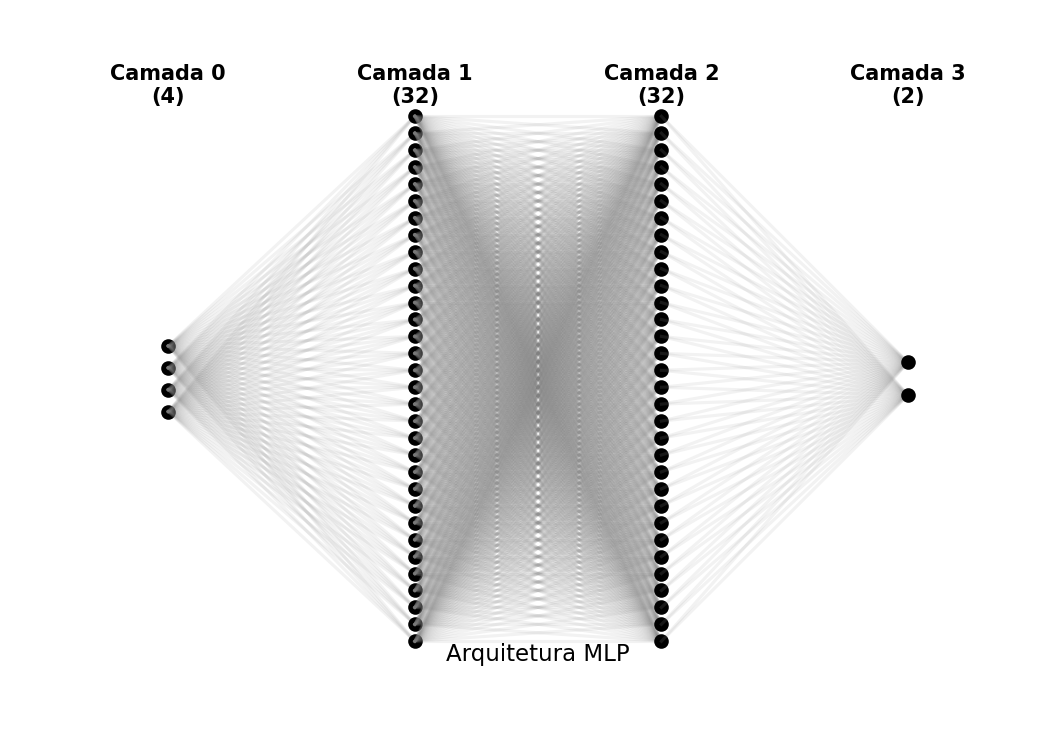

In [ ]:
plot_mlp_arquitetura(layers, grid, save_img)

##Gráficos

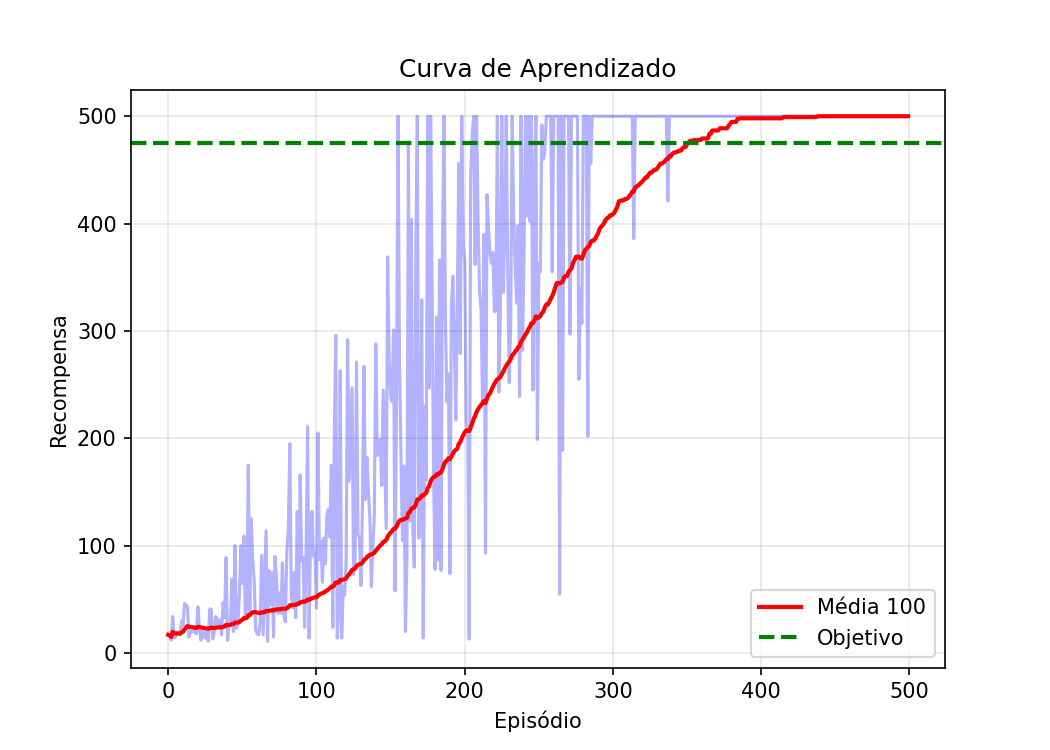

In [ ]:
plot_curva_aprendizado(rewards, save_img)

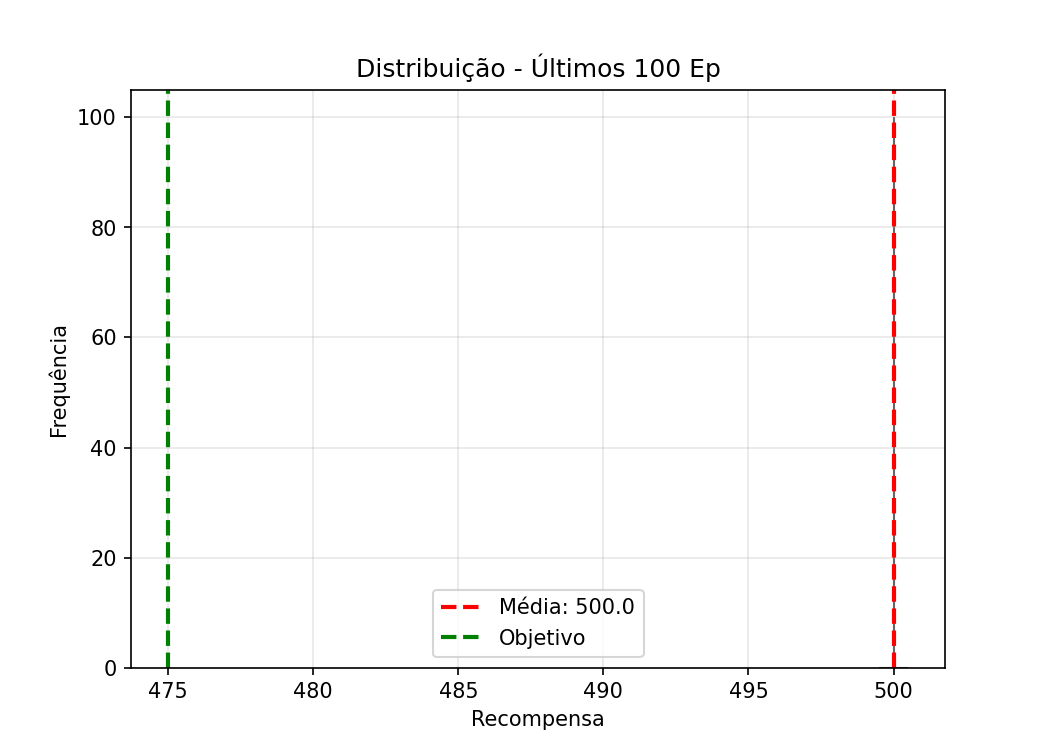

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

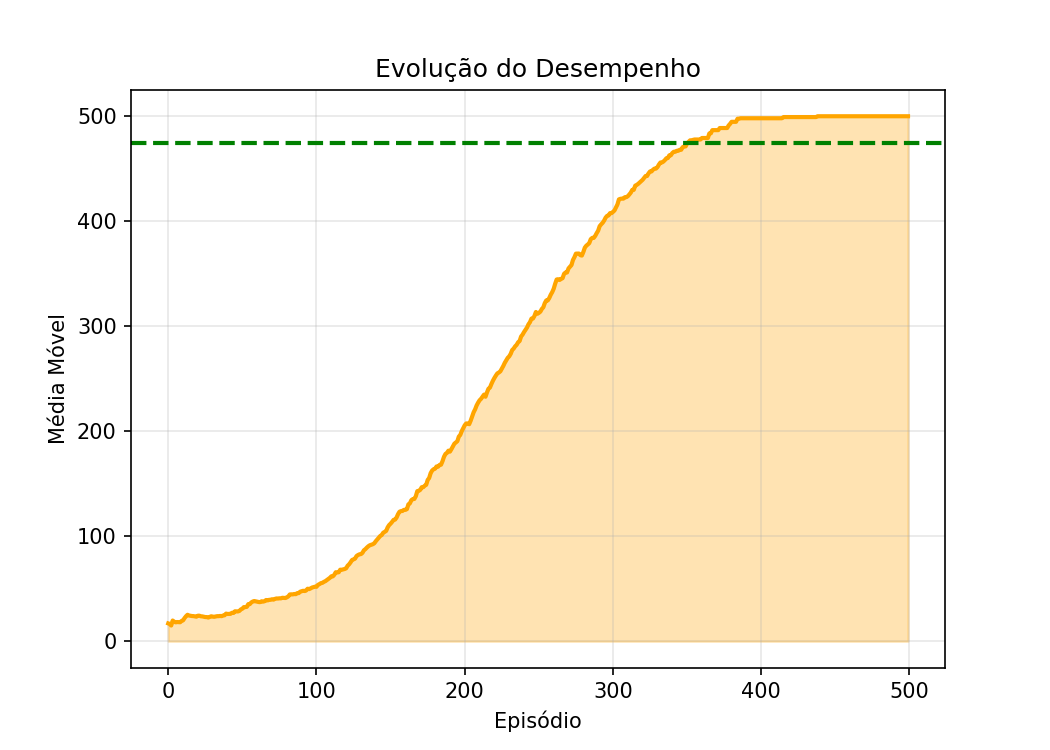

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

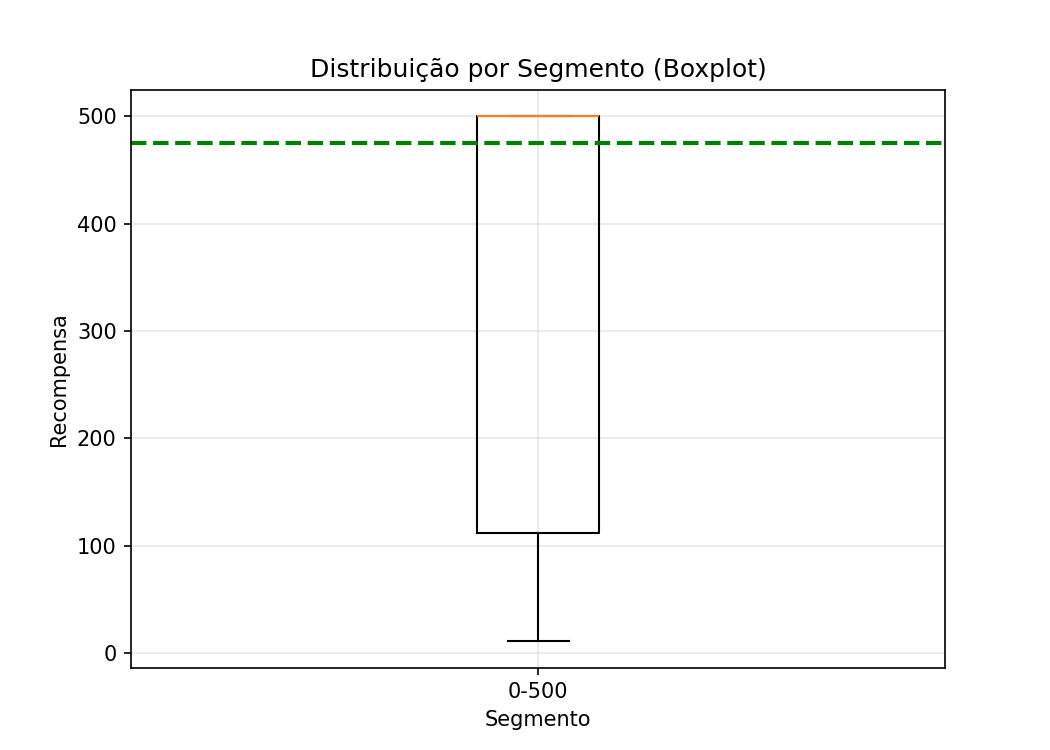

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

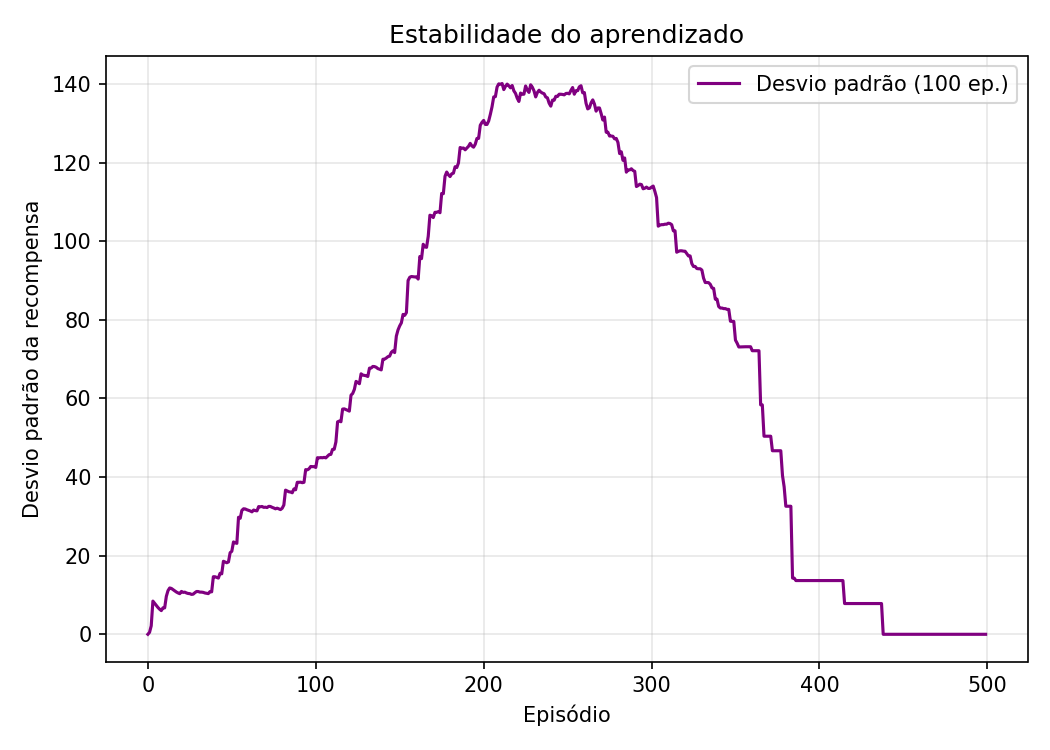

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

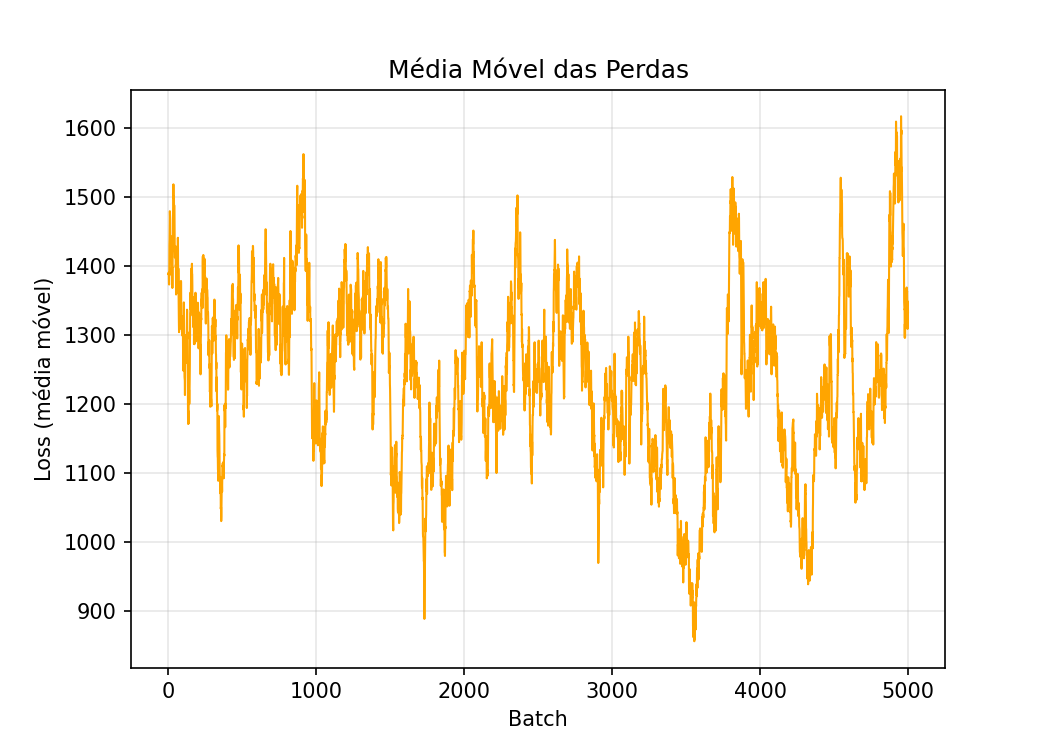

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_5d98dbebc0.pt
Vídeo gerado: videos/video-19d73558be-episode-0.mp4
Recompensa total: 419.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_5d98dbebc0.pt
Vídeo gerado: videos/video-7870c3ae09-episode-0.mp4
Recompensa total: 427.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_5d98dbebc0.pt
Vídeo gerado: videos/video-e69eb41563-episode-0.mp4
Recompensa total: 418.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_5d98dbebc0.pt
Vídeo gerado: videos/video-3dd54ddfbf-episode-0.mp4
Recompensa total: 500.00


In [ ]:
plot_video(env, layers, gamma, save_res, nome_agente, lr)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/mlp_agente_5d98dbebc0.pt
Vídeo gerado: videos/video-b39ef4af65-episode-0.mp4
Recompensa total: 311.00
